In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [3]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

In [4]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())

In [5]:
CF_solar = PV_data.mean(axis = 1) # average all the years

In [6]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()

print(OnshoreWind_Data.head())

                     NATIONAL      DK01      DK02      DK03      DK04  \
time                                                                    
1980-01-01 00:00:00  0.100020  0.169258  0.154797  0.058525  0.082945   
1980-01-01 01:00:00  0.095627  0.157692  0.155743  0.059855  0.076598   
1980-01-01 02:00:00  0.090815  0.145822  0.156026  0.060255  0.070185   
1980-01-01 03:00:00  0.082520  0.134984  0.153629  0.058150  0.058770   
1980-01-01 04:00:00  0.071892  0.122622  0.150896  0.054550  0.042691   

                         DK05  
time                           
1980-01-01 00:00:00  0.120442  
1980-01-01 01:00:00  0.112279  
1980-01-01 02:00:00  0.103703  
1980-01-01 03:00:00  0.092318  
1980-01-01 04:00:00  0.080078  


In [7]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

In [8]:
def plot_quarterly_distribution(data_series, years_to_show=[2021, 2022, 2023, 2024], label="Wind"):
    """
    Creates a grouped boxplot for specified years grouped by quarter.
    """
    # 1. Convert Series to DataFrame for easier plotting
    df = data_series.to_frame(name='Capacity_Factor')
    
    # 2. Ensure the index is datetime and extract Year/Quarter
    df.index = pd.to_datetime(df.index)
    df['Year'] = df.index.year
    df['Quarter'] = 'Q' + df.index.quarter.astype(str)
    
    # 3. Filter for the years you want to look at
    filtered_df = df[df['Year'].isin(years_to_show)]
    
    # 4. Calculate Stats (Mean, Min, Max) for your reference
    stats = filtered_df.groupby(['Year', 'Quarter'])['Capacity_Factor'].agg(['mean', 'min', 'max']).round(3)
    print(f"--- Statistics for {label} ---")
    print(stats)
    
    # 5. Visualization
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Boxplot shows Min, Max, and Quarters. 
    # 'hue' allows the comparison between years.
    sns.boxplot(x='Quarter', y='Capacity_Factor', hue='Year', data=filtered_df, palette="pastel")
    
    # Adding mean markers (red dots)
    sns.pointplot(x='Quarter', y='Capacity_Factor', hue='Year', data=filtered_df, 
                  estimator='mean', dodge=0.5, color='red', markers='d', linestyles='')

    plt.title(f'Quarterly {label} Capacity Factor: {min(years_to_show)} - {max(years_to_show)}')
    plt.ylabel('Capacity Factor (0 to 1)')
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

--- Statistics for Wind ---
               mean    min    max
Year Quarter                     
2021 Q1       0.271  0.007  0.890
     Q2       0.200  0.005  0.805
     Q3       0.198  0.002  0.913
     Q4       0.299  0.011  0.817
2022 Q1       0.352  0.008  0.965
     Q2       0.205  0.003  0.811
     Q3       0.208  0.006  0.696
     Q4       0.302  0.017  0.831
2023 Q1       0.324  0.008  0.958
     Q2       0.203  0.003  0.743
     Q3       0.224  0.010  0.915
     Q4       0.350  0.003  0.955
2024 Q1       0.347  0.015  0.944
     Q2       0.233  0.005  0.780
     Q3       0.218  0.012  0.869
     Q4       0.293  0.002  0.895


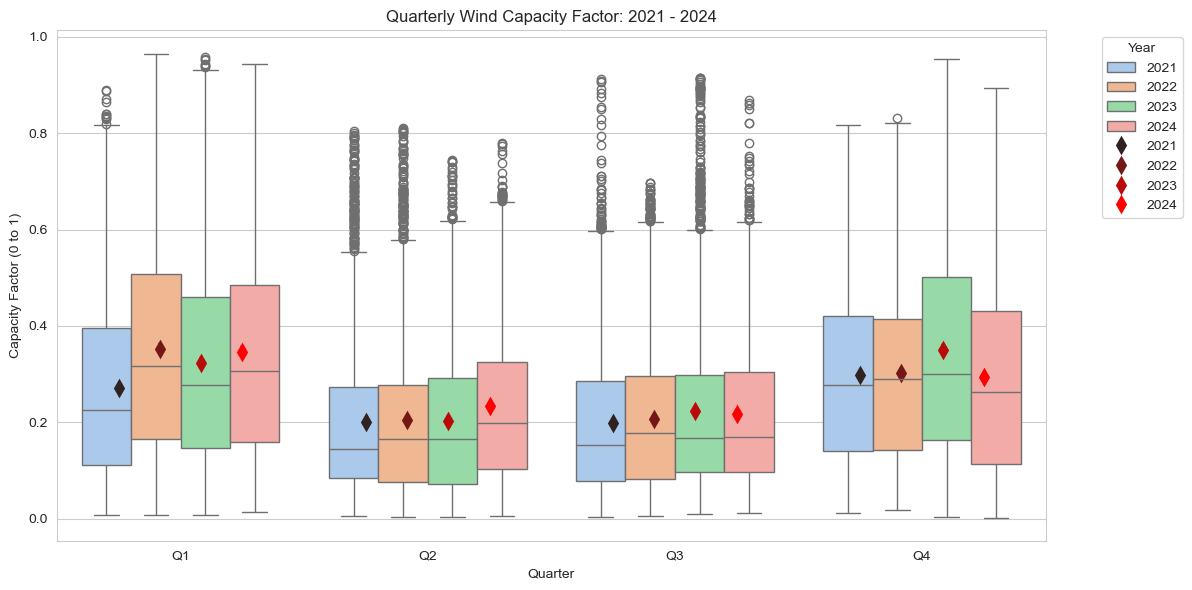

--- Statistics for Solar ---
               mean  min    max
Year Quarter                   
2021 Q1       0.066  0.0  0.652
     Q2       0.189  0.0  0.729
     Q3       0.171  0.0  0.677
     Q4       0.039  0.0  0.519
2022 Q1       0.078  0.0  0.639
     Q2       0.193  0.0  0.715
     Q3       0.175  0.0  0.700
     Q4       0.045  0.0  0.557
2023 Q1       0.058  0.0  0.624
     Q2       0.214  0.0  0.734
     Q3       0.162  0.0  0.678
     Q4       0.035  0.0  0.540
2024 Q1       0.053  0.0  0.622
     Q2       0.181  0.0  0.711
     Q3       0.169  0.0  0.684
     Q4       0.041  0.0  0.570


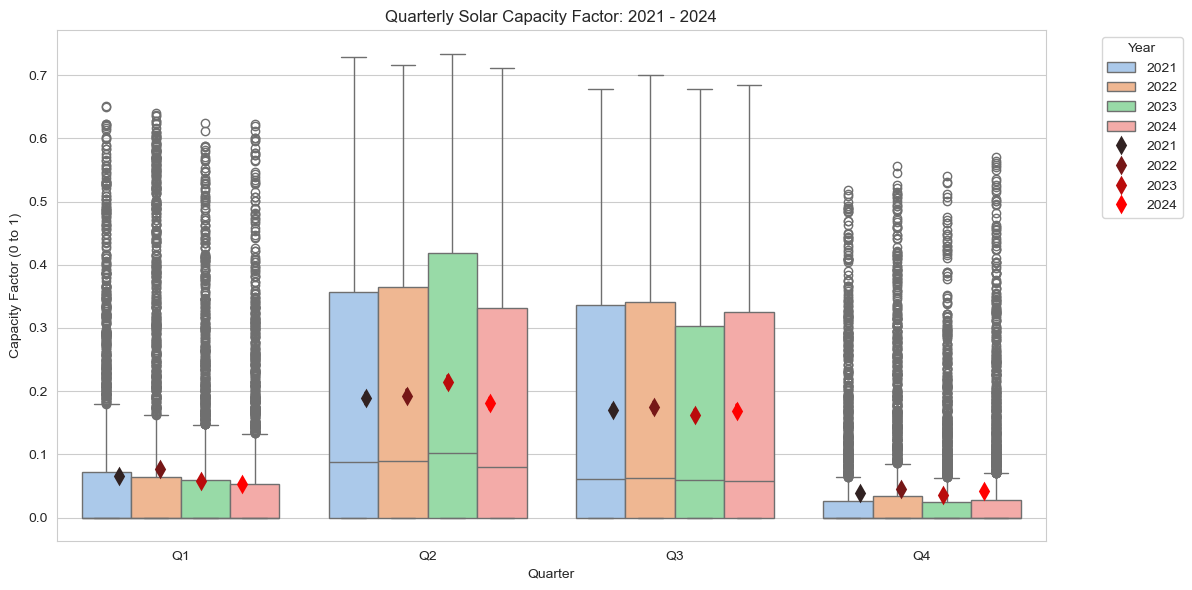

In [9]:
# For Wind:
plot_quarterly_distribution(CF_wind, years_to_show=[2021,2022, 2023, 2024], label="Wind")

# For Solar:
plot_quarterly_distribution(CF_solar, years_to_show=[2021,2022, 2023, 2024], label="Solar")

In [10]:
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
gas_price_pre_oct_2021.tail()

,GasDay,Created,BalanceType,Balance,ProductCode,greenZoneMin,greenZoneMax,YellowZoneMin,YellowZoneMax,GasBuyingPriceDKK,GasBuyPriceDescription,GasSellingPriceDKK,GasSellPriceDescription
15861,2022-09-30 00:00:00,2022-10-01 01:45:15,ESCB,3166032,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15862,2022-09-30 00:00:00,2022-09-30 22:45:23,ESCB,3537232,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15863,2022-09-30 00:00:00,2022-10-31 07:28:17,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15864,2022-09-30 00:00:00,2022-11-09 13:28:53,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15865,2022-09-30 00:00:00,2022-09-30 06:46:05,ESCB,-4450243,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN


In [11]:
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]

In [12]:
gas_price_data = pd.read_excel(gas_file)

In [13]:
# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [14]:
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)

In [15]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

(462336.0, 462408.0)

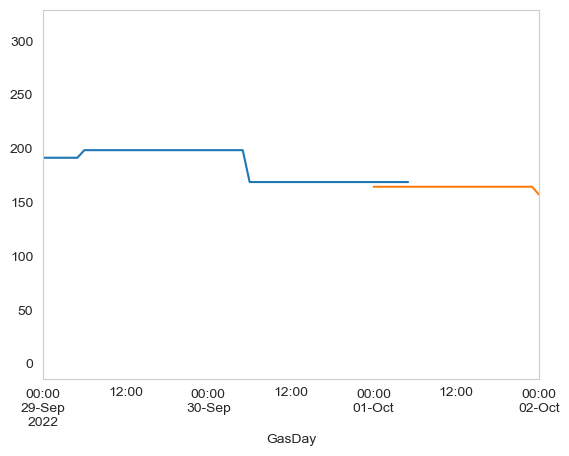

In [16]:
(gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"]*(1000/7.45)).plot()
gas_price_hourly["MarginalPurchasePriceEUR_MWh"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.grid()
plt.xlim("2022-09-29","2022-10-02")

In [17]:
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])

In [18]:
gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"].isna().sum()

0

In [19]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"][gas_price_hourly["MarginalPurchasePriceEUR_MWh"].isna()]

GasDay
2023-04-01 00:00:00   NaN
2023-04-01 01:00:00   NaN
2023-04-01 02:00:00   NaN
2023-04-01 03:00:00   NaN
2023-04-01 04:00:00   NaN
2023-04-01 05:00:00   NaN
2023-04-01 06:00:00   NaN
2023-04-01 07:00:00   NaN
2023-04-01 08:00:00   NaN
2023-04-01 09:00:00   NaN
2023-04-01 10:00:00   NaN
2023-04-01 11:00:00   NaN
2023-04-01 12:00:00   NaN
2023-04-01 13:00:00   NaN
2023-04-01 14:00:00   NaN
2023-04-01 15:00:00   NaN
2023-04-01 16:00:00   NaN
2023-04-01 17:00:00   NaN
2023-04-01 18:00:00   NaN
2023-04-01 19:00:00   NaN
2023-04-01 20:00:00   NaN
2023-04-01 21:00:00   NaN
2023-04-01 22:00:00   NaN
2023-04-01 23:00:00   NaN
Freq: h, Name: MarginalPurchasePriceEUR_MWh, dtype: float64

In [20]:
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

In [21]:
NG_price.isna().sum()


MarginalPurchasePriceEUR_MWh    0
dtype: int64

In [22]:
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh

In [23]:
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}

In [24]:
def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    # 1. Year Filter & Column Selection (Fixes DateParseError)
    year_str = str(year)
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # 2. Settings & Conversion (øre/kWh to EUR/MWh)
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45 
    
    # 3. Define Logic Windows
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_peak_time = hours.hour.isin(range(17, 21)) # 17:00 to 20:59
    is_day_time = hours.hour.isin(range(6, 24))   # 06:00 to 23:59

    # 4. Apply Net Tariff Levels
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    net_tariff.loc[is_day_time] = d["el_tariff_high"]
    net_tariff.loc[is_winter & is_peak_time] = d["el_tariff_peak"]

    # 5. Calculate Final Prices
    fixed_fees = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    buy_price = spot + (fixed_fees + net_tariff) * DKK_to_EUR_MWh
    
    # Selling = Spot minus production costs
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price
    

In [25]:
import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")

In [26]:

def plot_pypsa_heatmap(data, title="PyPSA Heatmap", unit="Value", cmap="viridis", ax=None, vmin=None, vmax=None):
    """
    Added vmin and vmax for manual scale control.
    """
    if isinstance(data, pd.DataFrame):
        plot_data = data.mean(axis=1)
    else:
        plot_data = data

    df = plot_data.to_frame(name="values")
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    
    pivot = df.pivot_table(index="date", columns="hour", values="values", aggfunc='mean')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Pass vmin and vmax here
    sns.heatmap(pivot, cmap=cmap, cbar_kws={'label': unit}, ax=ax, 
                rasterized=True, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date")

In [27]:
def add_carriers(n):
    #n.add("Carrier",'electricity grid im')
    #n.add("Carrier","electricity grid ex") 
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    n.add("Carrier","electric boiler")
    #n.add("Carrier","Rondo charge")
    #n.add("Carrier","Rondo store")
    #n.add("Carrier","Rondo discharge")
    n.add("Carrier","heat")
    n.add("Carrier","battery storage")
    n.add("Carrier","electricity")
    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    n.add("Carrier", "pellets") 
    n.add("Carrier", "CO2") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis")
    n.add("Carrier", "hydrogen")
    n.add("Carrier", "methanol")
    n.add("Carrier", "electrolysis")
    
    n.add("Carrier", "biomass")
    n.add("Carrier", "biochar")
    n.add("Carrier", "methane")


In [ ]:
def add_skive_generators(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "EuroWind" ,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 36)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "EuroWind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54)

    #--------------------------------
    # PPA link
    n.add("Link", "PPA",
          bus0="EuroWind",
          bus1="Greenlab",
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity")

In [605]:
# Check the maximum capacity the solver decided to build for the PPA
print(f"PPA Optimized Capacity: {n21.links.at['PPA', 'p_nom_opt']} MW")

PPA Optimized Capacity: 32.53150057273769 MW


In [29]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          efficiency=1.0,
          marginal_cost=5e-6,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="EuroWind",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="EuroWind",
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)

In [30]:
def add_battery(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="EuroWind",  # Use your electricity bus name
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [111]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        #e_nom= e_nom_store, # MWh
        e_nom_extendable=True,
        e_nom_min = e_nom_store,
        e_nom_max = e_nom_store,
        e_initial=0,
        e_cyclic=True,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=True,
        p_nom_min = p_nom_charge,
        p_nom_max = p_nom_charge, 
        # p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        #p_nom = p_nom_discharge,
        p_nom_extendable=True,
        p_nom_min = p_nom_discharge,
        p_nom_max = p_nom_discharge,
        efficiency=0.90,
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [32]:
# 2 Heat Exchanger hence effincecy = 0.9*0.9 = 0.81
def add_heat_exchanger(n):
    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_MT", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)

In [607]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        #p_nom = 10, # MW,
        p_nom_extendable = True,
        p_nom_min = 10,
        p_nom_max = 10,
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"],
        marginal_cost = costs.at["electric boiler steam","marginal_cost"])

In [34]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        capital_cost = costs.at["decentral gas boiler","capital_cost"],
        marginal_cost = NG_price + CO2tax, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,
        capital_cost=5772) 
    

In [583]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t

    n.add("Store",
    "pellets store",
     bus = "pellets",
     carrier = "pellets",
     e_nom_extendable = True)
    
    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="Greenlab",
        bus3="biochar",
        efficiency= 3.7859/7.6748, #"biochar pyrolysis", "heat output" (MWh_th/t_CO2)/ "biochar pyrolysis", "biomass input (MWh_biomass/t_CO2), #bus1 devided by bus0.
        efficiency2= -0.3184/7.6748,   #-"biochar pyrolysis", "electricity input"] (MWh_e/t_CO2) / "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2),
        efficiency3=  1/7.6748,  #1 / "biochar pyrolysis", biochar output (waste*),
        marginal_cost= 2.5909/7.6748, #"biomass HOP", "VOM" (EUR/MWh)/ "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2)? #     
        p_nom_extendable=False,
        p_nom=2,
        carrier="pyrolysis",
        capital_cost=233477) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom_extendable = True,
        marginal_cost=-0.164*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="biochar") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="biochar")

In [418]:
# DH_Price = 40 - 60 EUR/MWh
def add_heat_load(n,p_load,DH_cost):

    n.add("Link","MT_Heat_Supply",
        bus0="Heat_MT",
        bus1="Heat_Sink",
        p_nom_extendable=True,
        carrier = "heat",
        marginal_cost = -DH_cost,) # MWh

    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_Sink",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = p_load) # MWh

In [419]:
#Fixed demand
def add_el_load(n,p_el):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load",  "Skive_el_Load", 
        bus="Greenlab", 
        p_set= p_el,
        carrier = "electricity") #MWh

In [573]:
def biogas_plant(n):

    #n.add("Generator",
     #   "Biomass",
      #  bus= "Biogas_Feedstock",
       # carrier="biomass",
       # p_nom_extendable=True,
       # marginal_cost = 25)  # 25 EUR/t biomass
    
    n.add("Store","Biomass Store",
            bus = "Biogas_Feedstock",
            e_nom = 11000 ,
            e_initial = 11000,
            e_min_pu = 0,
            e_cyclic = False,
            carrier = "biomass",
            marginal_cost = 0)
    
    # 2.09 t/h of biomass inputs

    n.add("Link",
    "BiogasPlant",
    bus0 = "Biogas_Feedstock", # input: Feedstock
    bus1 = "Greenlab", # input: electrcity
    bus2 = "Heat_MT", # input: heat
    bus3 = "pellets", # output: Pellets
    bus4 = "Biogas", # ouptut: CH4 
    bus5 = "Co2", # output: Co2
    p_nom_extendable = True,
    p_min_pu = 0,
    capital_cost = costs.at["biogas","capital_cost"],
    efficiency =  -0.02/2.09, # el input (MW)
    efficiency2 = -0.05/2.09, # heat input (MW)
    efficiency3 =  0.12/2.09, # Pellets output (MW)
    efficiency4  = 1/2.09,  # Biogas (CH4) output (MW)
    efficiency5 = 0.1/2.09, # co2 (t/h)
    )

    n.add("Store", "Biogas_Store",
    bus = "Biogas",
    marginal_cost = -100,
    e_nom_extendable = True,)



In [550]:
n22 = build_network(CO2_tax = 80,p_import = import_price22 ,p_export = export_price22,NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2022"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00, 10.06it/s]
INFO:linopy.io: Writing time: 7.31s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 33720 iterations and 9.47 seconds (13.05 work units)


INFO:gurobipy:Solved in 33720 iterations and 9.47 seconds (13.05 work units)


Optimal objective -3.101312120e+07


INFO:gurobipy:Optimal objective -3.101312120e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 324139 primals, 727102 duals
Objective: -3.10e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [585]:
n21 = build_network(CO2_tax = 80,p_import = import_price21 ,p_export = export_price21,NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00,  9.93it/s]
INFO:linopy.io: Writing time: 8.1s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 83996 iterations and 13.69 seconds (15.96 work units)


INFO:gurobipy:Solved in 83996 iterations and 13.69 seconds (15.96 work units)


Optimal objective -1.186216394e+07


INFO:gurobipy:Optimal objective -1.186216394e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 341426 primals, 752867 duals
Objective: -1.19e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [587]:
n24 = build_network(CO2_tax = 80,p_import = import_price24 ,p_export = export_price24,NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00,  9.67it/s]
INFO:linopy.io: Writing time: 7.56s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 84915 iterations and 15.68 seconds (16.82 work units)


INFO:gurobipy:Solved in 84915 iterations and 15.68 seconds (16.82 work units)


Optimal objective -9.703502851e+06


INFO:gurobipy:Optimal objective -9.703502851e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 342596 primals, 755447 duals
Objective: -9.70e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [586]:
used_biomass = n21.stores_t.e["Biomass Store"].iloc[0] - n21.stores_t.e["Biomass Store"].iloc[-1]
print(f"Total biomass consumed: {used_biomass} units")

Total biomass consumed: 0.0 units


In [577]:
print(n21.buses_t.marginal_price["Biogas"].mean())

-100.0


In [589]:
n21.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,p_nom_opt,bus3,efficiency3,bus2,efficiency2,bus5,efficiency5,bus4,efficiency4,marignal_cost
Link,,,,,,,,,,,,,,,,,,,,,
PPA,EuroWind,Greenlab,,electricity,0.970000,True,0,inf,0.0,0.0,...,24.742268,,1.000000,,1.000000,,1.000000,,1.000000,NaN
Imports,Grid_Import,EuroWind,,electricity,0.970000,True,0,inf,84.0,0.0,...,84.000000,,1.000000,,1.000000,,1.000000,,1.000000,NaN
Exports,EuroWind,Grid_Export,,electricity,0.970000,True,0,inf,84.0,0.0,...,84.000000,,1.000000,,1.000000,,1.000000,,1.000000,NaN
Electrolyser,Greenlab,H2_Bus,,electrolysis,0.600000,True,0,inf,12.0,0.0,...,0.000000,,1.000000,,1.000000,,1.000000,,1.000000,NaN
BiogasPlant,Biogas_Feedstock,Greenlab,,biomass,-0.009569,True,0,inf,0.0,0.0,...,0.000000,pellets,0.057416,Heat_MT,-0.023923,Co2,0.047847,Biogas,0.478469,NaN
methanolisation,H2_Bus,methanol_bus,,methanol,0.878735,True,0,inf,0.0,0.0,...,0.000000,Co2,-0.217926,Greenlab,-0.238137,,1.000000,,1.000000,NaN
El_to_TES_Rondo,Greenlab,TES_Rondo,,electricity,0.980000,True,0,inf,0.0,0.0,...,24.000000,,1.000000,,1.000000,,1.000000,,1.000000,NaN
TES_Rondo_to_Heat_Bus_Skive,TES_Rondo,Heat_Exchanger_Bus,,heat,0.900000,True,0,inf,0.0,0.0,...,7.000000,,1.000000,,1.000000,,1.000000,,1.000000,NaN
Heat_Exchanger_Rondo,Heat_Exchanger_Bus,Heat_MT,,heat,0.800000,True,0,inf,0.0,0.0,...,0.000000,,1.000000,,1.000000,,1.000000,,1.000000,NaN


In [603]:
# Check if any bus has an extreme shadow price (meaning it's the bottleneck)
print(n21.buses_t.marginal_price.abs().max())

Bus
Greenlab                 638.882585
EuroWind                 619.716107
Grid_Import                0.000005
Grid_Export                0.000000
H2_Bus                   115.062943
pellets                   62.000000
NG                       249.463087
Heat_Exchanger_Bus       203.643337
TES_Rondo                218.387330
Heat_MT                  254.554171
biochar                   13.120000
biochar sequestration      0.000000
Heat_Sink                254.554171
dtype: float64


<Axes: xlabel='snapshot'>

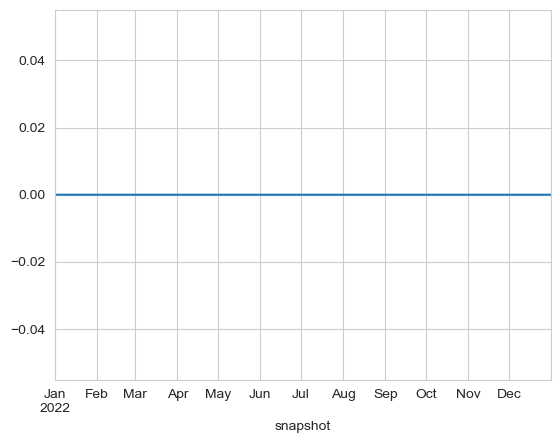

In [601]:
n22.links_t.p0["methanolisation"].plot()

<Axes: xlabel='snapshot'>

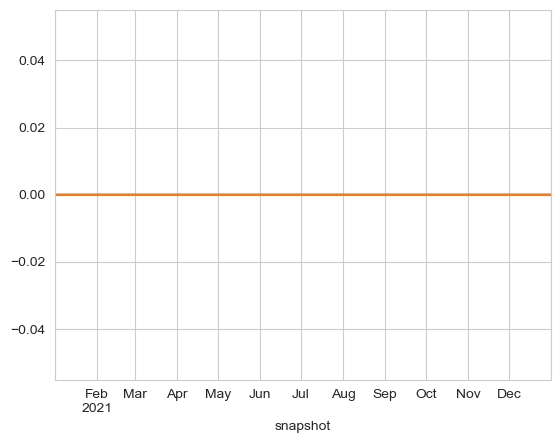

In [594]:
n21.links_t.p3["pyrolysis"].plot()
n21.links_t.p3["BiogasPlant"].plot()

In [576]:
# The correct attribute for Locational Marginal Prices (LMP)
print(n21.buses_t.marginal_price["Greenlab"].mean())

0.10008358449210464


In [ ]:
#n21.model.solver_model.computeIIS()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))


INFO:gurobipy:Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))


INFO:gurobipy:


CPU model: AMD Ryzen 7 8845HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]


INFO:gurobipy:CPU model: AMD Ryzen 7 8845HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]


...

INFO:gurobipy:


IIS computation: interrupted


INFO:gurobipy:IIS computation: interrupted


IIS runtime: 923.22 seconds (964.19 work units)


INFO:gurobipy:IIS runtime: 923.22 seconds (964.19 work units)


In [ ]:
# After the computeIIS() finishes:
n.model.solver_model.write("conflict_report.ilp")

In [588]:
def add_Co2_Store(n):
    n.add("Store", "Co2_Dump",
    bus = "Co2", carrier = "CO2",
    e_nom_extendable = True)

In [37]:
eff_h2 = 1 / costs.at["methanolisation", "hydrogen-input"]
costs.at["methanolisation", "capital_cost"] * eff_h2

130222.11082461492

In [393]:
"Methanolisation";
def add_methanolisation(n, p_min):
    n.add("Link",
     "methanolisation",
     bus0 = "H2_Bus",
     bus1 = "methanol_bus",
     bus2 = "Greenlab",
     bus3 = "Co2",  # Co2 from byproduct of biogas plant
     #p_nom = 10, # 10 MW methanol plant,
     p_nom_extendable = True,
     p_min_pu = p_min,
     carrier = "methanol",
     capital_cost = costs.at["methanolisation", "capital_cost"]*eff_h2,
     efficiency = eff_h2, # 0.87 , methanol output 
     efficiency2 = -costs.at["methanolisation", "electricity-input"]*eff_h2, # - 0.23 , electricty input
     efficiency3 = -costs.at["methanolisation", "carbondioxide-input"]*eff_h2 , # - 0.218 , Co2 input
     )

    n.add("Store",
    "methanol storage",
    bus="methanol_bus",
    carrier="methanol",
    capital_cost=costs.at["General liquid hydrocarbon storage (crude)", "capital_cost"] / (15.6 * 1000 / 3600),
    e_nom_extendable=True,
    e_cyclic=False,)

In [39]:
"Adding Electrolyser"
def add_electrolyser(n, P_elec):
    n.add("Link",
    "Electrolyser",
    bus0 = "Greenlab",
    bus1 = "H2_Bus",
    p_nom = P_elec,
    p_nom_extendable = True,
    carrier = "electrolysis",
    p_min_pu = 0.15,
    #p_nom_min = , 
    #p_nom_max = ,
    capital_cost = costs.at["Alkaline electrolyzer medium size", "capital_cost"],
    marginal_cost = costs.at["Alkaline electrolyzer medium size", "marginal_cost"],
    efficiency = 0.6,)

    n.add("Store",
    "H2_Storage",
    bus = "H2_Bus",
    capital_cost = costs.at["hydrogen storage tank type 1 including compressor", "capital_cost"],
    e_nom_extendable = True,
    carrier = "hydrogen",
    e_cylic = True)

In [40]:
# We don´t need this
def add_H2_demand(n,P_H2):
    n.add("Load",
    "H2 Demand",
    bus = "H2_Bus",
    carrier = "hydrogen",
    p_set = P_H2)

In [ ]:
def build_network(CO2_tax,p_import, p_export, NG_price, horizon):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    # Add carriers and base infrastructure
    add_carriers(n)

    # --- Bus Definitions ---
    # Electricity Buses
    n.add("Bus", "Greenlab", carrier="electricity")
    n.add("Bus", "EuroWind", carrier="electricity")
    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")
    
    # Gas & Fuel Buses
    n.add("Bus", "H2_Bus", carrier="hydrogen")
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")
    n.add("Bus", "methanol_bus", carrier="methanol")
    n.add("Bus", "NG", carrier="gas")
    
    # Heat & Solids
    n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")

    # --- Add Production & Storage Components ---
    add_battery(n, P_nom=22, max_t=2, cyclic_operation=True)
    add_skive_generators(n, s_cf, w_cf)
    add_grid(n, p_import, p_export)
    add_electrolyser(n, P_elec=12)
    
    # Biogas Plant Setup
    biogas_plant(n) 
    add_Co2_Store(n)
    
    add_methanolisation(n, p_min  = 0.1) 


    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)
    add_SkyClean(n, CO2_tax)

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            solver_name="gurobi", 
            horizon=horizon)
    else:
        # Full Year Optimization
        n.optimize(
            solver_name="gurobi",)

    return n

In [553]:
def build_network(CO2_tax,P_MeOH ,p_import, p_export, NG_price, horizon):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    # Add carriers and base infrastructure
    add_carriers(n)

    # --- Bus Definitions ---
    # Electricity Buses
    n.add("Bus", "Greenlab", carrier="electricity")
    n.add("Bus", "EuroWind", carrier="electricity")
    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")
    
    # Gas & Fuel Buses
    n.add("Bus", "H2_Bus", carrier="hydrogen")
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")
    n.add("Bus", "methanol_bus", carrier="methanol")
    n.add("Bus", "NG", carrier="gas")
    
    # Heat & Solids
    n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")

    # --- Add Production & Storage Components ---
    add_battery(n, P_nom=22, max_t=2, cyclic_operation=True)
    add_skive_generators(n, s_cf, w_cf)
    add_grid(n, p_import, p_export)
    add_electrolyser(n, P_elec=12)
    
    # Biogas Plant Setup
    biogas_plant(n) 
    add_Co2_Store(n)
    
    add_methanolisation(n, p_min  = 0.1) 


    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)
    add_SkyClean(n, CO2_tax)

    # --- Custom Constraint Function ---
    def add_custom_constraints(n, snapshots):
        """
        Combined constraints for Methanol production target and Biomass supply limit.
        Uses .sum() to allow flexibility within the optimization window.
        """
        # 1. METHANOL: Lower Bound (At least P_MeOH)
        # We target the methanolisation link output
        link_meoh = "methanolisation"
        eff_meoh = n.links.at[link_meoh, "efficiency"]
        p_meoh_in = n.model.variables['Link-p'].sel(Link=link_meoh)
        
        # Target production for the current window
        meoh_target = P_MeOH * len(snapshots) 
        
        n.model.add_constraints(
            (p_meoh_in * eff_meoh).sum() == meoh_target, 
            name="Methanol_Annual_Balance"
        )

        # 2. BIOMASS: Upper Bound (At most 500,000 t/y)
        # Target the 'Biomass' generator output variable
       # p_biomass = n.model.variables['Generator-p'].sel(Generator="Biomass")
        
        # Scale 500,000 t/y for the current window
       # biomass_limit_hourly = 500000 / 8760
        #current_window_limit = biomass_limit_hourly * len(snapshots)
        
        #n.model.add_constraints(
            #p_biomass.sum() <= current_window_limit, 
            #name="Global_Biomass_Limit")

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            solver_name="gurobi", 
            horizon=horizon,
            extra_functionality=add_custom_constraints
        )
    else:
        # Full Year Optimization
        n.optimize(
            solver_name="gurobi",
            extra_functionality=add_custom_constraints
        )

    return n

In [ ]:
def biogas_plant_as_load_gen(n):
    # --- Decoupled Biogas Plant Components ---
    # Feedstock Supply
    n.add("Generator", "Biomass_Supply", bus="Biogas_Feedstock", p_nom_extendable=True, marginal_cost=25)
    n.add("Store", "Biomass_Store", bus="Biogas_Feedstock", e_nom_extendable=True)

    # Inputs (Sinks/Loads): p_max_pu=0 forces them to only consume energy
    n.add("Generator", "Biogas_Intake", bus="Biogas_Feedstock", p_nom_extendable=True, p_max_pu=0)
    n.add("Generator", "Biogas_Elec_Cons", bus="Greenlab", p_nom_extendable=True, p_max_pu=0)
    n.add("Generator", "Biogas_Heat_Cons", bus="Heat_MT", p_nom_extendable=True, p_max_pu=0)

    # Outputs (Sources/Generators)
    n.add("Generator", "Biomethane_Gen", bus="Biogas", p_nom_extendable=True)
    n.add("Generator", "Biogas_CO2_Gen", bus="Co2", p_nom_extendable=True)

    # --- Custom Constraint Function ---
    def add_custom_constraints(n, snapshots):
        vars = n.model.variables
        gen_p = vars['Generator-p']

        # Variables for coupling
        p_intake = gen_p.sel(Generator="Biogas_Intake")
        p_elec = gen_p.sel(Generator="Biogas_Elec_Cons")
        p_heat = gen_p.sel(Generator="Biogas_Heat_Cons")
        p_methane = gen_p.sel(Generator="Biomethane_Gen")
        p_co2 = gen_p.sel(Generator="Biogas_CO2_Gen")

        # Coupling Constraints: Output = Intake * Ratio
        # p_intake is negative, so we negate it (-p_intake) for positive math
        n.model.add_constraints(p_methane == -p_intake * (1.0 / 2.09), name="Biogas_CH4_Coupling")
        n.model.add_constraints(p_co2 == -p_intake * (0.1 / 2.09), name="Biogas_CO2_Coupling")
        
        # Consumption Ratios: Elec = 0.048 MW per 2.09 t/h
        n.model.add_constraints(p_elec == p_intake * (0.048 / 2.09), name="Biogas_Elec_Coupling")
        n.model.add_constraints(p_heat == p_intake * (0.15 / 2.09), name="Biogas_Heat_Coupling")


In [249]:
def build_network(CO2_tax, p_import, p_export, NG_price, horizon):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    # Add carriers and base infrastructure
    add_carriers(n)

    # --- Bus Definitions ---
    # Electricity Buses
    n.add("Bus", "Greenlab", carrier="electricity")
    n.add("Bus", "EuroWind", carrier="electricity")
    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")
    
    # Gas & Fuel Buses
    #n.add("Bus", "H2_Bus", carrier="hydrogen")
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")
    #n.add("Bus", "methanol_bus", carrier="methanol")
    n.add("Bus", "NG", carrier="gas")
    
    # Heat & Solids
    n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")

    # --- Add Production & Storage Components ---
    add_battery(n, P_nom=22, max_t=2, cyclic_operation=True)
    add_skive_generators(n, s_cf, w_cf)
    add_grid(n, p_import, p_export)
    #add_electrolyser(n, P_elec=12)
    
    # Biogas Plant Setup
    biogas_plant(n) 
    add_Co2_Store(n)
    
    #add_methanolisation(n, p_min) 


    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)
    add_SkyClean(n, CO2_tax)

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            solver_name="gurobi", 
            horizon=horizon,
            #extra_functionality=add_custom_constraints
        )
    else:
        # Full Year Optimization
        n.optimize(
            solver_name="gurobi",
           # extra_functionality=add_custom_constraints
        )

    return n

In [510]:
n21 = build_network(CO2_tax = 80,p_import = import_price21 ,p_export = export_price21,NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"] ,horizon= None)


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00, 10.72it/s]
INFO:linopy.io: Writing time: 7.33s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 0 iterations and 0.36 seconds (0.35 work units)


INFO:gurobipy:Solved in 0 iterations and 0.36 seconds (0.35 work units)


Infeasible or unbounded model


INFO:gurobipy:Infeasible or unbounded model
INFO:linopy.solvers:Unable to save solution file. Raised error: No solution available
Status: warning
Termination condition: infeasible_or_unbounded
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: 4



<Axes: xlabel='snapshot'>

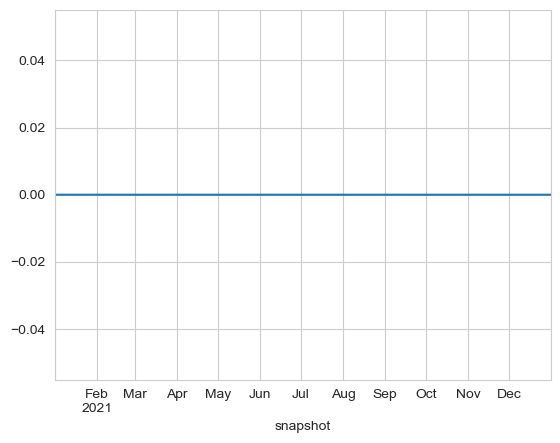

In [498]:
n21.links_t.p1["BiogasPlant"].plot()

<Axes: xlabel='snapshot'>

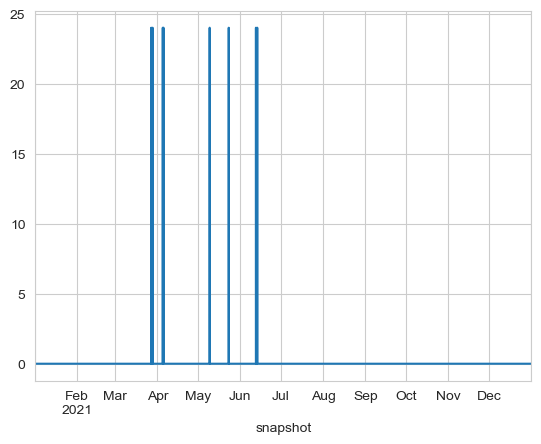

In [499]:
n21.links_t.p0["El_to_TES_Rondo"].plot()

In [372]:
0.048*10

0.48

In [365]:
"P_CH4 {MW} -> Methanol Output";
def add_biogas_plant(n, P_CH4):
    # 1. FIX THE OUTPUT CAPACITY (The Methane "Generator")
    # This is the P_CH4 capacity you want to fix
    n.add("Generator", "biomethane_output",
          bus="Biogas", 
          carrier="methane",
          p_nom_extendable = True,
          P_nom = P_CH4,
          p_min_pu = 0.1)

    # 2. ADD THE INPUT LOADS (Attached to correct buses)
    # Ratios are based on your 2.09 t/h feedstock vs 1 MW CH4 logic
    n.add("Load", "el_biogas_cons",
          bus="Greenlab", # Corrected Bus
          carrier="electricity",
          p_set=0.048/1.0 * P_CH4) # Scaled electricity input {0.02 + 0.008 + 0.2}

    n.add("Load", "heat_biogas_cons",
          bus="Heat_MT", # Corrected Bus
          carrier="heat",
          p_set=0.15/1.0 * P_CH4) # Scaled heat input {0.1 + 0.05}

    # 3. ADD BYPRODUCTS
    n.add("Generator", "pellets_from_biogas",
          bus="pellets", # Corrected Bus
          carrier="pellets",
          p_nom=0.12/1.0 * P_CH4) # Scaled pellet output
    
    n.add("Generator", "co2_from_biogas",
          bus="Co2",
          carrier="CO2",
          p_nom=0.1/1.0 * P_CH4) # Scaled CO2 output
    

    n.add("Store", "Methane_Store",
    bus = "Biogas", carrier = "methane",
    e_nom_extendable = True,)

In [366]:
def build_network(CO2_tax, P_CH4, p_import, p_export, NG_price, horizon):
    n = pypsa.Network()
    n.set_snapshots(NG_price.index)

    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    add_carriers(n)

    # --- Bus Definitions ---
    n.add("Bus", "Greenlab", carrier="electricity")
    n.add("Bus", "EuroWind", carrier="electricity")
    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")
    
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")
    n.add("Bus", "NG", carrier="gas")
    
    n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")

    
    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")

    # --- Add Production & Storage Components ---
    add_battery(n, P_nom=22, max_t=2, cyclic_operation=True)
    add_skive_generators(n, s_cf, w_cf)
    add_grid(n, p_import, p_export)
    
    # Biogas Plant Setup
    add_biogas_plant(n, P_CH4)
    add_Co2_Store(n)

    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)
    add_SkyClean(n, CO2_tax)

    # --- Define Constraints (Inside the builder for scope access) ---
    def add_custom_constraints(n, snapshots):
        # Access the Generator-p variables
        # Ensure the name "biomethane_output" matches exactly in add_biogas_plant
        gen_p = n.model.variables['Generator-p'].sel(Generator="biomethane_output")
        
        # Target: 200,000 MWh annual production
        target_mwh = (200000 / 8760) * len(snapshots)
        
        # Add the annual output constraint
        n.model.add_constraints(
            gen_p.sum() == target_mwh, 
            name="Annual_Biomethane_Output_Constraint"
        )

    # --- Solving Section ---
    # We must pass the FUNCTION REFERENCE, not call it
    if horizon is not None:
        n.optimize.optimize_with_rolling_horizon(
            solver_name="gurobi", 
            horizon=horizon,
            extra_functionality=add_custom_constraints
        )
    else:
        n.optimize(
            solver_name="gurobi",
            extra_functionality=add_custom_constraints
        )

    return n

In [362]:
200000/8760

22.831050228310502

In [367]:
n21 = build_network(CO2_tax = 80, P_CH4 = 30 ,p_import = import_price21 ,p_export = export_price21,NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:01<00:00,  9.81it/s]
INFO:linopy.io: Writing time: 6.4s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 17966 iterations and 9.88 seconds (2.65 work units)


INFO:gurobipy:Solved in 17966 iterations and 9.88 seconds (2.65 work units)


Optimal objective -7.133522313e+06


INFO:gurobipy:Optimal objective -7.133522313e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 271388 primals, 621553 duals
Objective: -7.13e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance, Annual_Biomethane_Output_Constraint were not assigned to the network.


In [479]:
n21.loads_t.p["el_biogas_cons"].plot()
n21.loads_t.p["heat_biogas_cons"].plot()

KeyError: 'el_biogas_cons'

In [480]:
n21.generators_t.p["biomethane_output"].plot()

KeyError: 'biomethane_output'

In [293]:
n22 = build_network(CO2_tax = 80, P_CH4 = 1 ,p_import = import_price22 ,p_export = export_price22,NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2022"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 11.15it/s]
INFO:linopy.io: Writing time: 6.0s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 41813 iterations and 5.35 seconds (1.46 work units)


INFO:gurobipy:Solved in 41813 iterations and 5.35 seconds (1.46 work units)


Optimal objective -2.994653131e+07


INFO:gurobipy:Optimal objective -2.994653131e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 271573 primals, 621977 duals
Objective: -2.99e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


<Axes: xlabel='snapshot'>

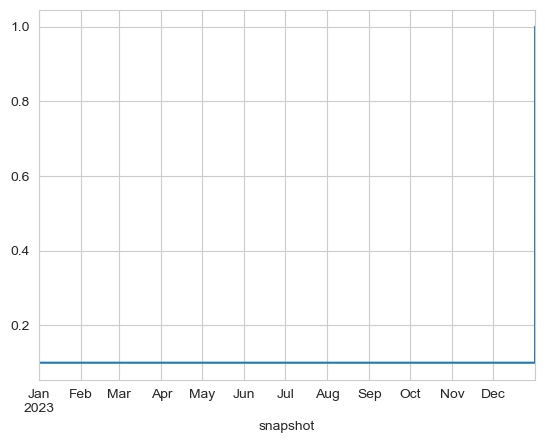

In [351]:
n23.generators_t.p["biomethane_output"].plot()

<Axes: xlabel='snapshot'>

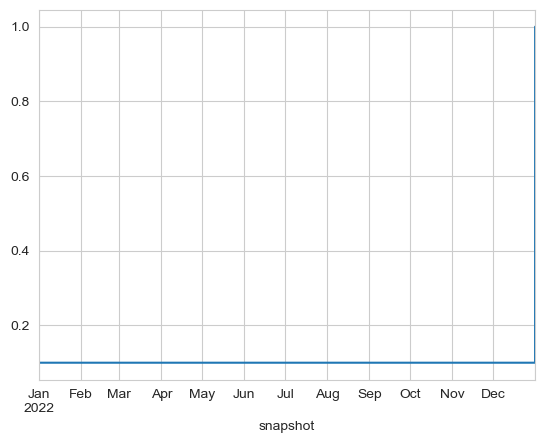

In [294]:
n22.generators_t.p["biomethane_output"].plot()

<Axes: xlabel='snapshot'>

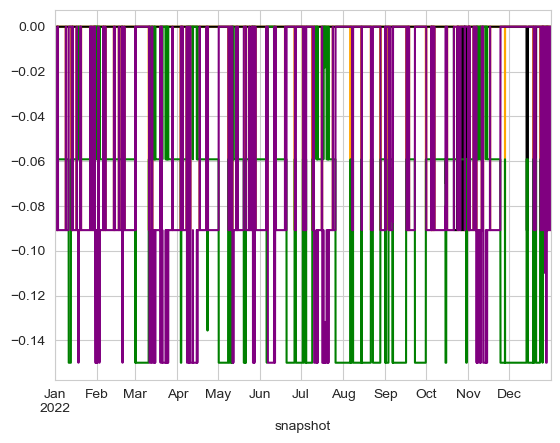

In [305]:
n22.links_t.p1["Boiler_Skive"].plot(color = "orange")
n22.links_t.p1["NG boiler"].plot(color = "black")
n22.links_t.p1["pyrolysis"].plot(color = "green")
n22.links_t.p1["Heat_Exchanger_Rondo"].plot(color = "purple")

In [344]:
def plot_dispatch_mix(n, components, title="Heat Source Dispatch", stacked=False):
    # 1. Select only the links that actually exist in the network
    existing_links = [l for l in components if l in n.links.index]
    
    # 2. Convert negative p1 (output) to positive MW
    dispatch_data = n.links_t.p1[existing_links].abs()
    
    if stacked:
        # High-level overview of the energy mix
        ax = dispatch_data.plot.area(figsize=(12, 6), alpha=0.7)
        ax.set_title(title)
        ax.set_ylabel("Heat Output [MW]")
        plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    else:
        # Detailed view to see each source clearly without overlap
        fig, axes = plt.subplots(len(existing_links), 1, figsize=(12, 3 * len(existing_links)), sharex=True)
        for i, name in enumerate(existing_links):
            dispatch_data[name].plot(ax=axes[i], title=f"Dispatch: {name}", grid=True)
            axes[i].set_ylabel("MW")
        plt.xlabel("Time")

    plt.tight_layout()
    plt.show()

In [380]:

def plot_heat_production(n, title="Annual Heat Production"):
    """
    Plots the annual heat production for RONDO, Electric Boiler, 
    NG Boiler, and Pyrolysis from a PyPSA network.
    """
    # 1. Define the links we are looking for
    target_links = {
        "RONDO": "Heat_Exchanger_Rondo",
        "Electric Boiler": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis"
    }
    
    # 2. Extract values safely (handles missing links with 0.0)
    data = {}
    for label, link_name in target_links.items():
        if link_name in n.links.index:
            # Note: we use .get() or check existence to avoid KeyErrors
            # Summing p1 (output) and converting MW -> GWh
            data[label] = (-n.links_t.p1[link_name].sum()) / 1e3
        else:
            data[label] = 0.0
            
    annual_heat = pd.Series(data)
    total_gwh = annual_heat.sum()
    
    # Avoid division by zero if network is empty/unsolved
    if total_gwh == 0:
        print("Warning: Total heat production is 0. Check if the network is solved.")
        return
    
    # 3. Aesthetics & Sorting
    nice_colors = {'RONDO': '#FFB74D', 'Electric Boiler': '#64B5F6', 
                   'NG Boiler': '#E57373', 'Pyrolysis': '#81C784'}
    
    annual_heat_sorted = annual_heat.sort_values(ascending=False)
    plot_colors = [nice_colors[idx] for idx in annual_heat_sorted.index]
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(annual_heat_sorted.index, annual_heat_sorted.values, 
                  color=plot_colors, edgecolor='white', linewidth=1)

    # 5. Data Labels
    for bar in bars:
        height = bar.get_height()
        label_idx = annual_heat_sorted.index[bars.index(bar)]
        pct = (height / total_gwh * 100)
        
        ax.text(bar.get_x() + bar.get_width()/2., height + (total_gwh * 0.01),
                f'{height:.1f} GWh\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=25)
    ax.set_ylabel("Total Heat Production [GWh]", fontsize=13)
    ax.set_xlabel("Technology", fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.6)
    
    plt.ylim(0, annual_heat_sorted.max() * 1.2)
    plt.tight_layout()
    plt.show()

# Usage:
# plot_heat_production(n21, title="2021 v2")

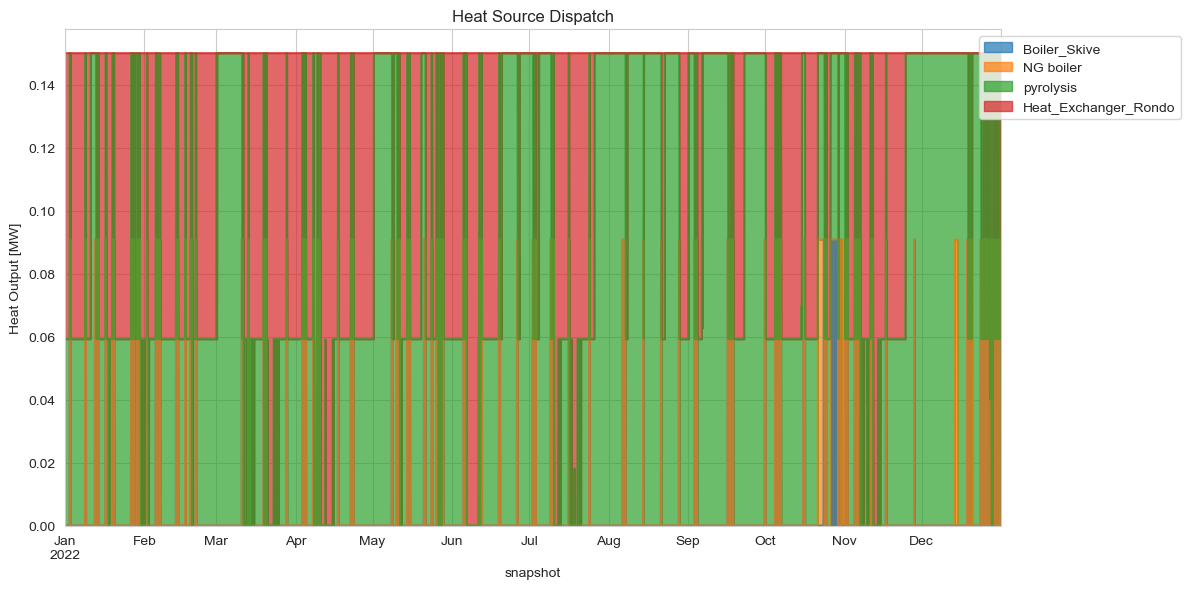

In [347]:

plot_dispatch_mix(n22, list(heat_components.keys()), stacked=True)

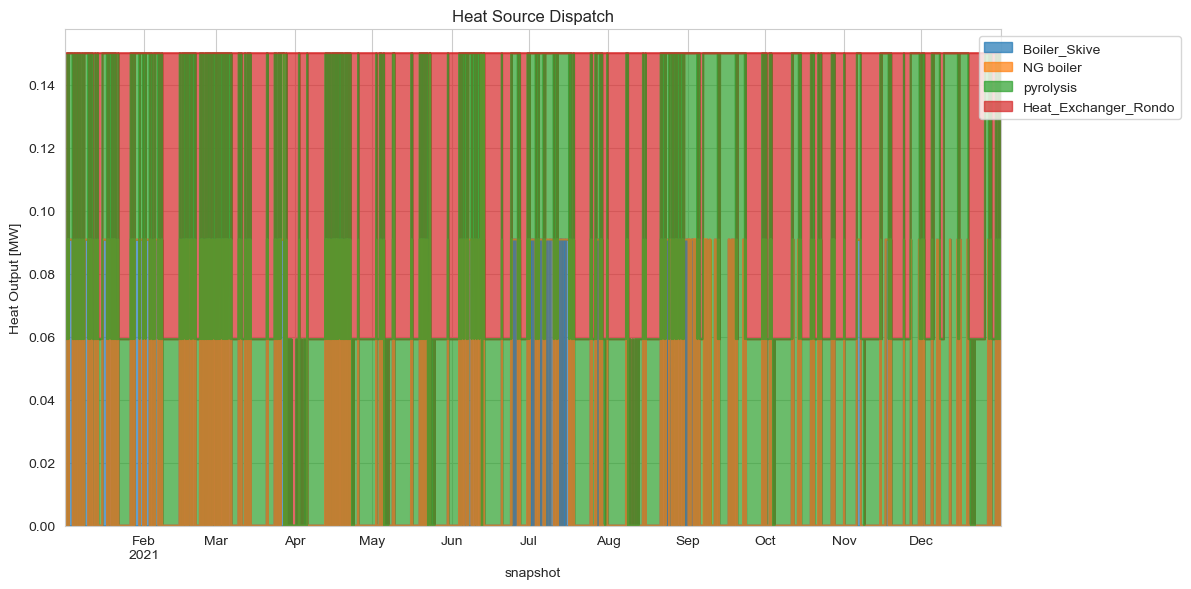

In [348]:

plot_dispatch_mix(n21, list(heat_components.keys()),stacked=True)

In [335]:
n23 = build_network(CO2_tax = 80, P_CH4 = 1 ,p_import = import_price23 ,p_export = export_price23,NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2023"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 11.54it/s]
INFO:linopy.io: Writing time: 5.76s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 42655 iterations and 5.57 seconds (1.44 work units)


INFO:gurobipy:Solved in 42655 iterations and 5.57 seconds (1.44 work units)


Optimal objective -1.135156744e+07


INFO:gurobipy:Optimal objective -1.135156744e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 271573 primals, 621977 duals
Objective: -1.14e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


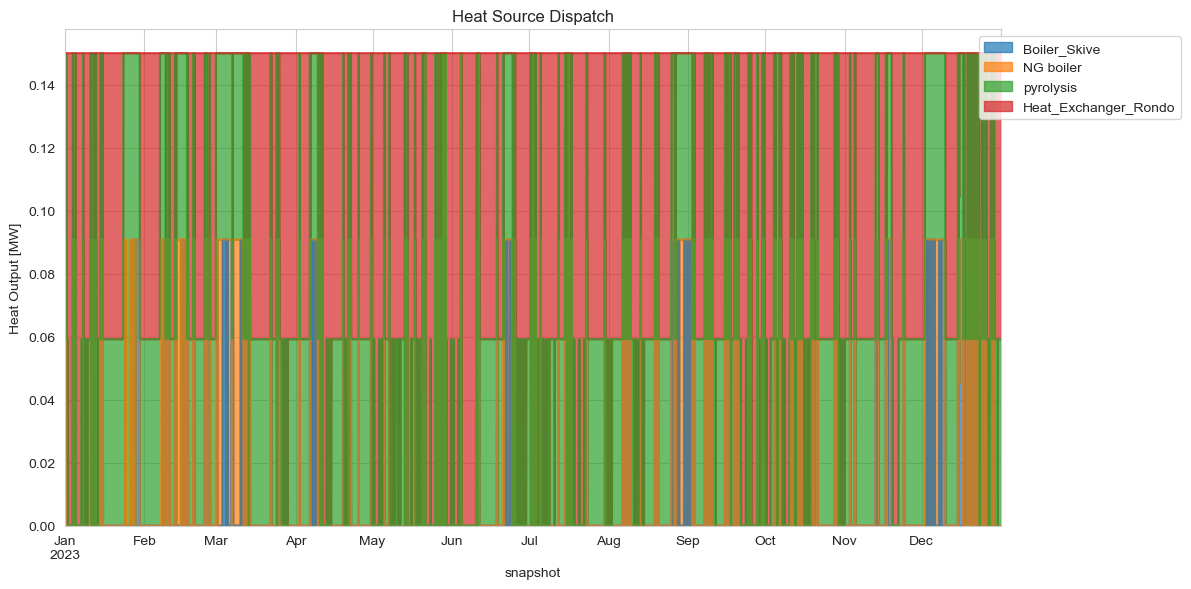

In [349]:
plot_dispatch_mix(n23, list(heat_components.keys()),  stacked=True)

In [337]:
n24 = build_network(CO2_tax = 80, P_CH4 = 20 ,p_import = import_price24 ,p_export = export_price24,NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 11.04it/s]
INFO:linopy.io: Writing time: 6.08s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 44031 iterations and 5.59 seconds (1.20 work units)


INFO:gurobipy:Solved in 44031 iterations and 5.59 seconds (1.20 work units)


Optimal objective -7.278597661e+06


INFO:gurobipy:Optimal objective -7.278597661e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 272317 primals, 623681 duals
Objective: -7.28e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


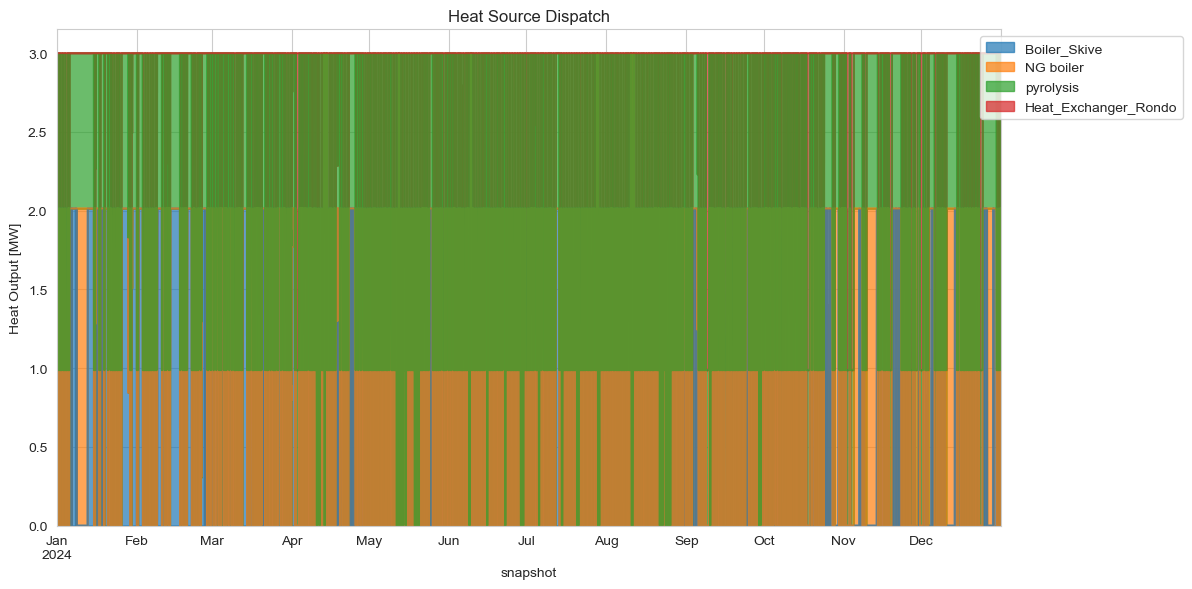

In [350]:
plot_dispatch_mix(n24, list(heat_components.keys()), stacked=True)

### Simple Netowrk w.o Methanolisation + Biogas Load {P_heat = 5, P_el = 2}

- simple fixed load for biogas plant

In [608]:
def build_network(CO2_tax,p_el ,p_heat,p_import, p_export, NG_price, horizon):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    # Add carriers and base infrastructure
    add_carriers(n)

    # --- Bus Definitions ---
    # Electricity Buses
    n.add("Bus", "Greenlab", carrier="electricity")
    n.add("Bus", "EuroWind", carrier="electricity")
    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")
    
    # Gas & Fuel Buses
    n.add("Bus", "H2_Bus", carrier="hydrogen")
    #n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    #n.add("Bus", "Biogas", carrier="methane")
    #n.add("Bus", "Co2", carrier="CO2")
    #n.add("Bus", "methanol_bus", carrier="methanol")
    n.add("Bus", "NG", carrier="gas")
    
    # Heat & Solids
    n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")
    n.add("Bus","Heat_Sink", carrier = "heat")

    add_el_load(n,p_el)

    add_heat_load(n,p_heat,DH_cost = 0)

    # --- Add Production & Storage Components ---
    add_battery(n, P_nom=22, max_t=2, cyclic_operation=True)
    add_skive_generators(n, s_cf, w_cf)
    add_grid(n, p_import, p_export)
    add_electrolyser(n, P_elec=12)
    
    # Biogas Plant Setup
    #biogas_plant(n) 
    #add_Co2_Store(n)
    
    #add_methanolisation(n, p_min  = 0.1) 


    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)
    add_SkyClean(n, CO2_tax)

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            solver_name="gurobi", 
            horizon=horizon,
            #extra_functionality=add_custom_constraints
        )
    else:
        # Full Year Optimization
        n.optimize(
            solver_name="gurobi",
            #extra_functionality=add_custom_constraints
        )

    return n

In [609]:
n21 = build_network(CO2_tax = 80 ,p_el = 2,p_heat = 5,p_import = import_price21, p_export = export_price21, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 13.44it/s]
INFO:linopy.io: Writing time: 5.95s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 37531 iterations and 15.50 seconds (2.18 work units)


INFO:gurobipy:Solved in 37531 iterations and 15.50 seconds (2.18 work units)


Optimal objective -6.421496019e+06


INFO:gurobipy:Optimal objective -6.421496019e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262636 primals, 604045 duals
Objective: -6.42e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


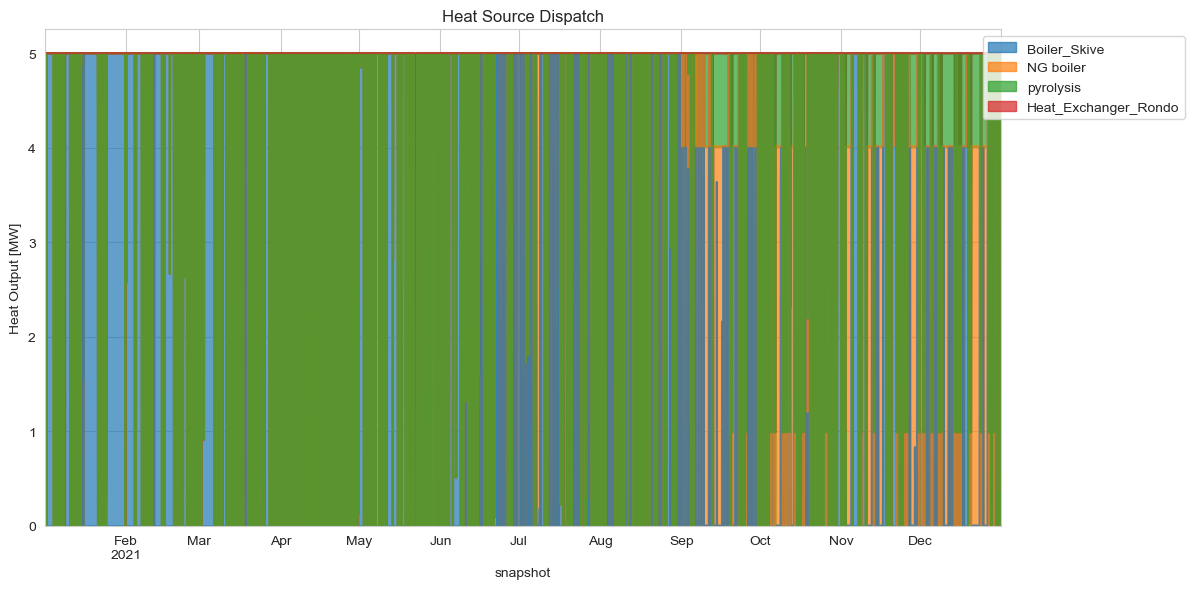

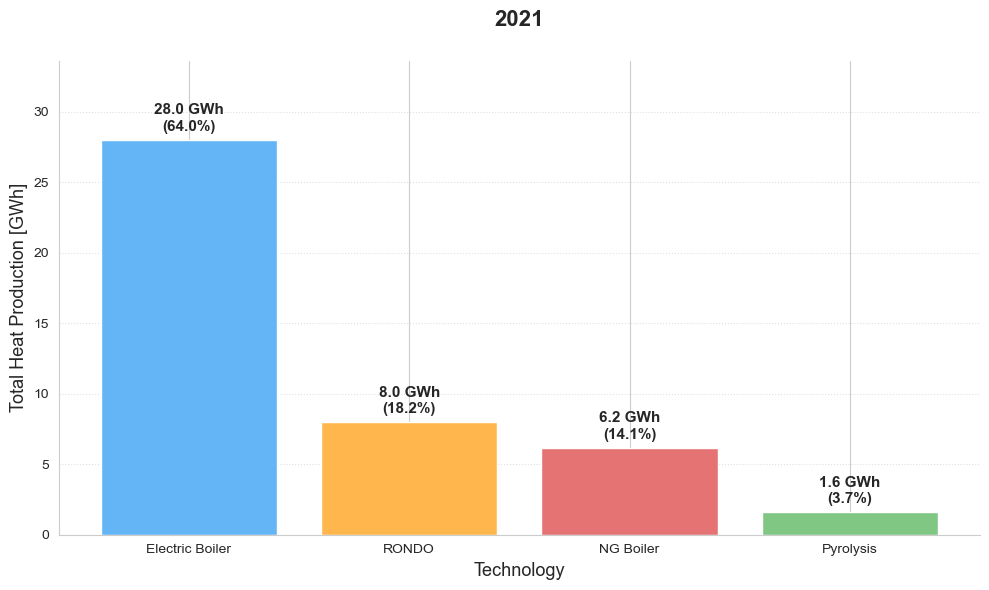

In [613]:
plot_dispatch_mix(n21, list(heat_components.keys()),  stacked=True)
plot_heat_production(n21, title="2021")

In [610]:
n22 = build_network(CO2_tax = 80 ,p_el = 2,p_heat = 5,p_import = import_price22, p_export = export_price22, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2022"], horizon = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 13.29it/s]
INFO:linopy.io: Writing time: 6.36s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 38802 iterations and 15.77 seconds (2.16 work units)


INFO:gurobipy:Solved in 38802 iterations and 15.77 seconds (2.16 work units)


Optimal objective -2.026605056e+07


INFO:gurobipy:Optimal objective -2.026605056e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262816 primals, 604459 duals
Objective: -2.03e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


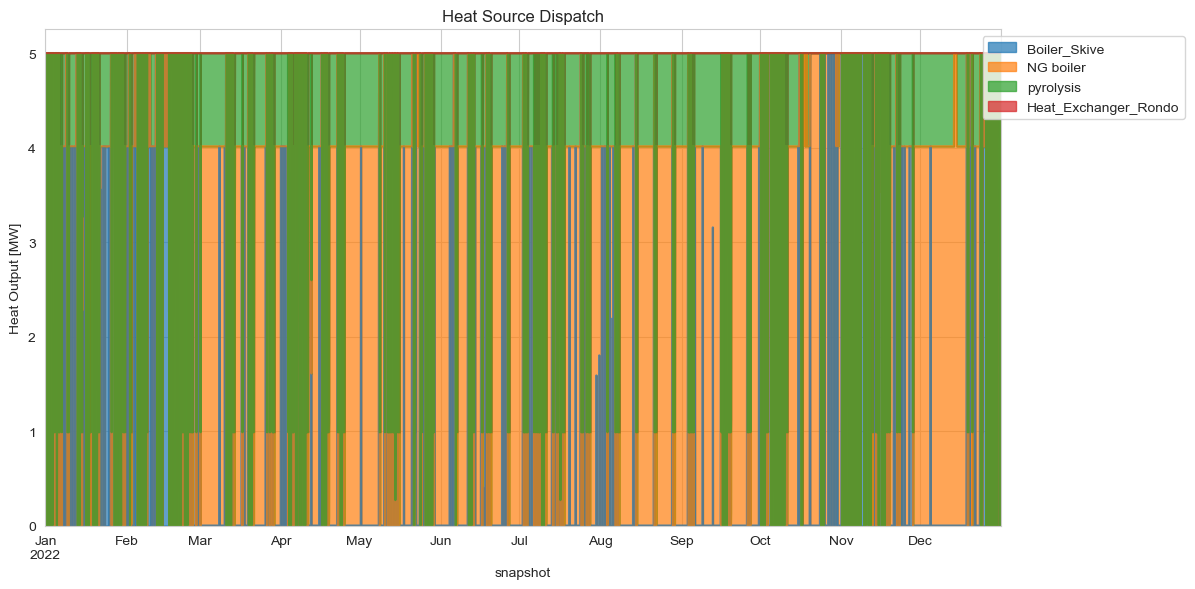

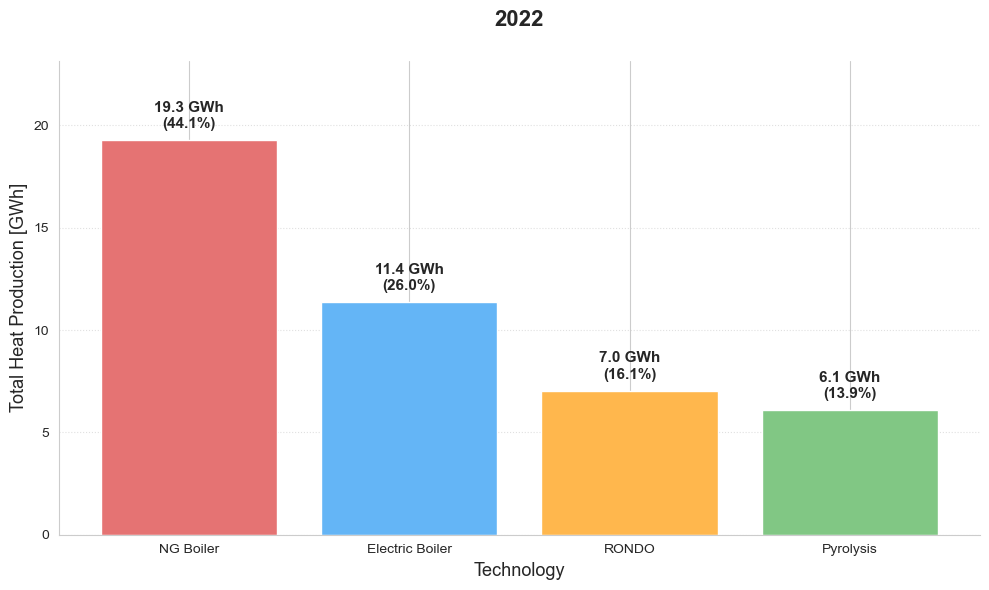

In [436]:
plot_dispatch_mix(n22, list(heat_components.keys()),  stacked=True)
plot_heat_production(n22, title="2022")

In [611]:
n23 = build_network(CO2_tax = 80 ,p_el = 2,p_heat = 5,p_import = import_price23, p_export = export_price23, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2023"], horizon = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 12.30it/s]
INFO:linopy.io: Writing time: 5.79s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 37626 iterations and 16.03 seconds (4.50 work units)


INFO:gurobipy:Solved in 37626 iterations and 16.03 seconds (4.50 work units)


Optimal objective -7.240628556e+06


INFO:gurobipy:Optimal objective -7.240628556e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262816 primals, 604459 duals
Objective: -7.24e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


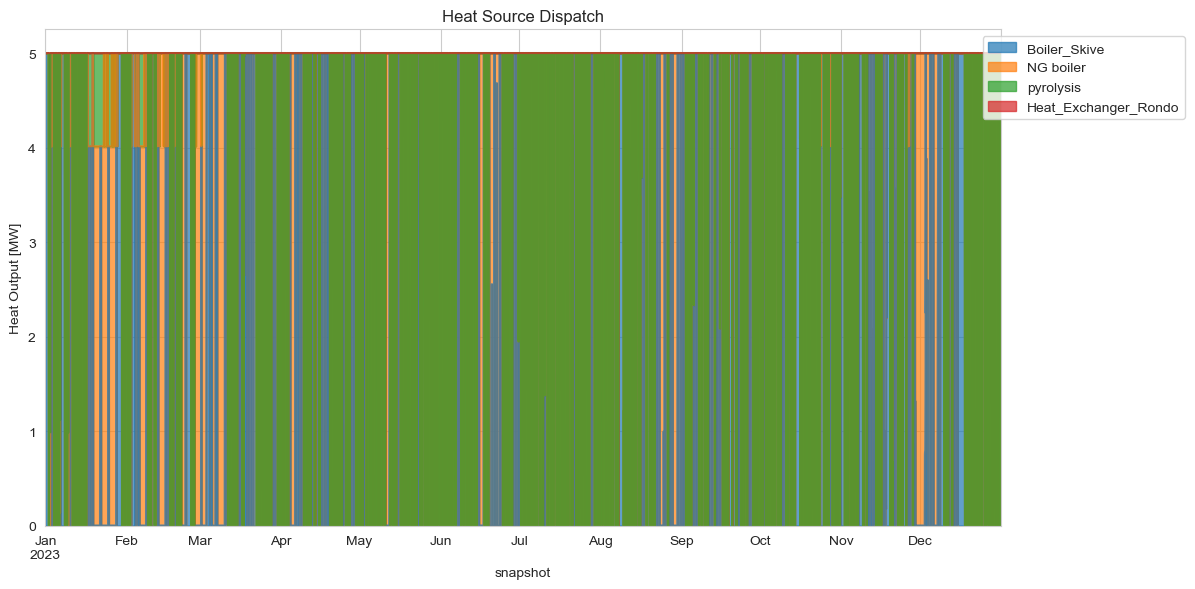

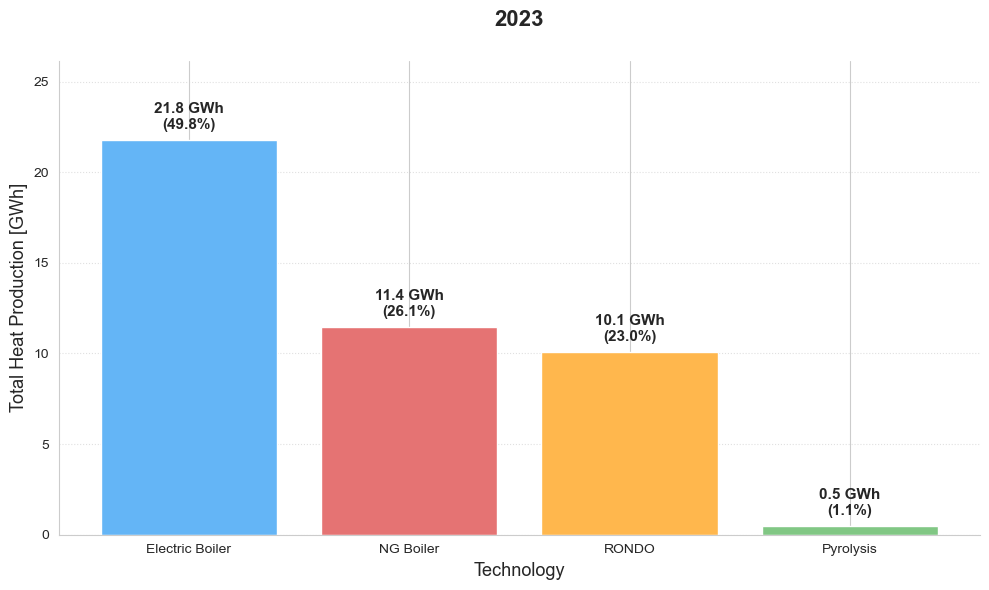

In [457]:
plot_dispatch_mix(n23, list(heat_components.keys()),  stacked=True)
plot_heat_production(n23, title="2023")

In [612]:
n24 = build_network(CO2_tax = 80 ,p_el = 2,p_heat = 5,p_import = import_price24, p_export = export_price24, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], horizon = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 12.60it/s]
INFO:linopy.io: Writing time: 6.06s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 135194 iterations and 16.98 seconds (14.92 work units)


INFO:gurobipy:Solved in 135194 iterations and 16.98 seconds (14.92 work units)


Optimal objective -5.704772246e+06


INFO:gurobipy:Optimal objective -5.704772246e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 263536 primals, 606115 duals
Objective: -5.70e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


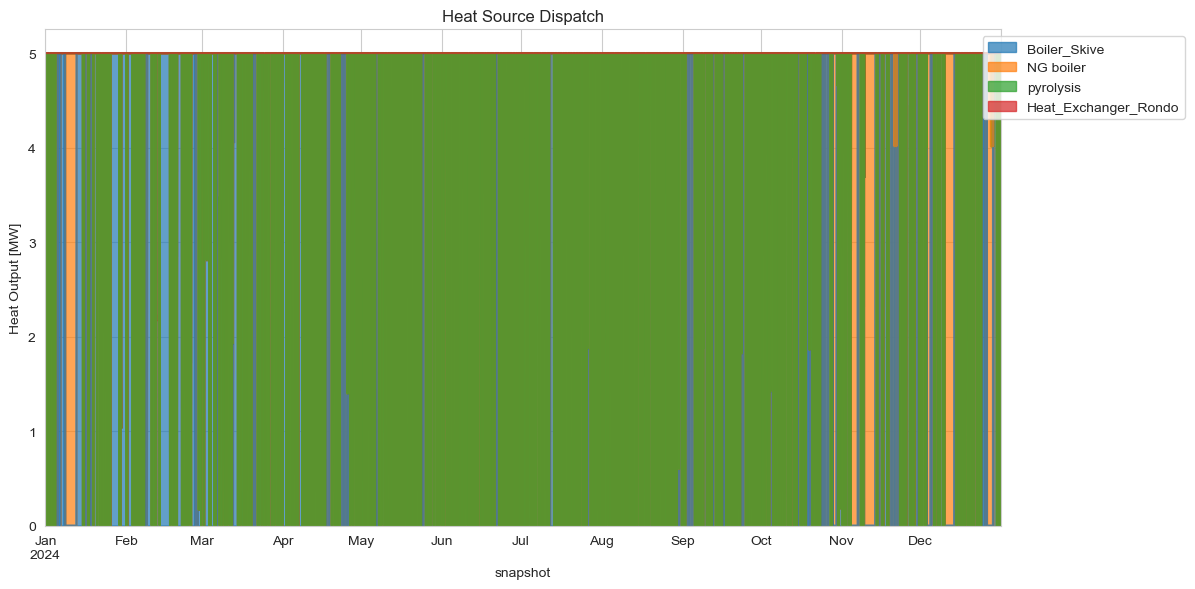

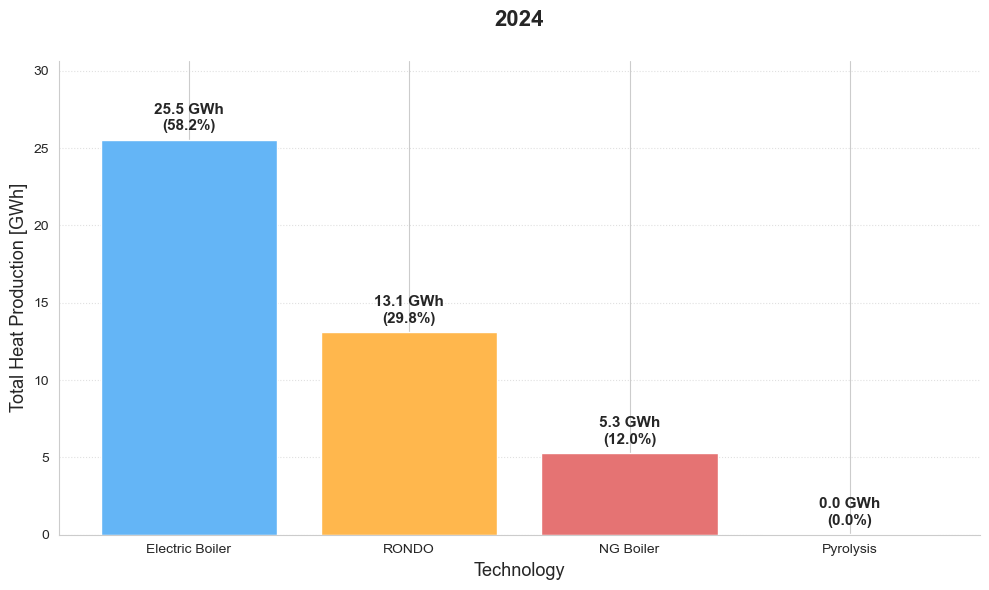

In [458]:
plot_dispatch_mix(n24, list(heat_components.keys()),  stacked=True)
plot_heat_production(n24, title="2024")

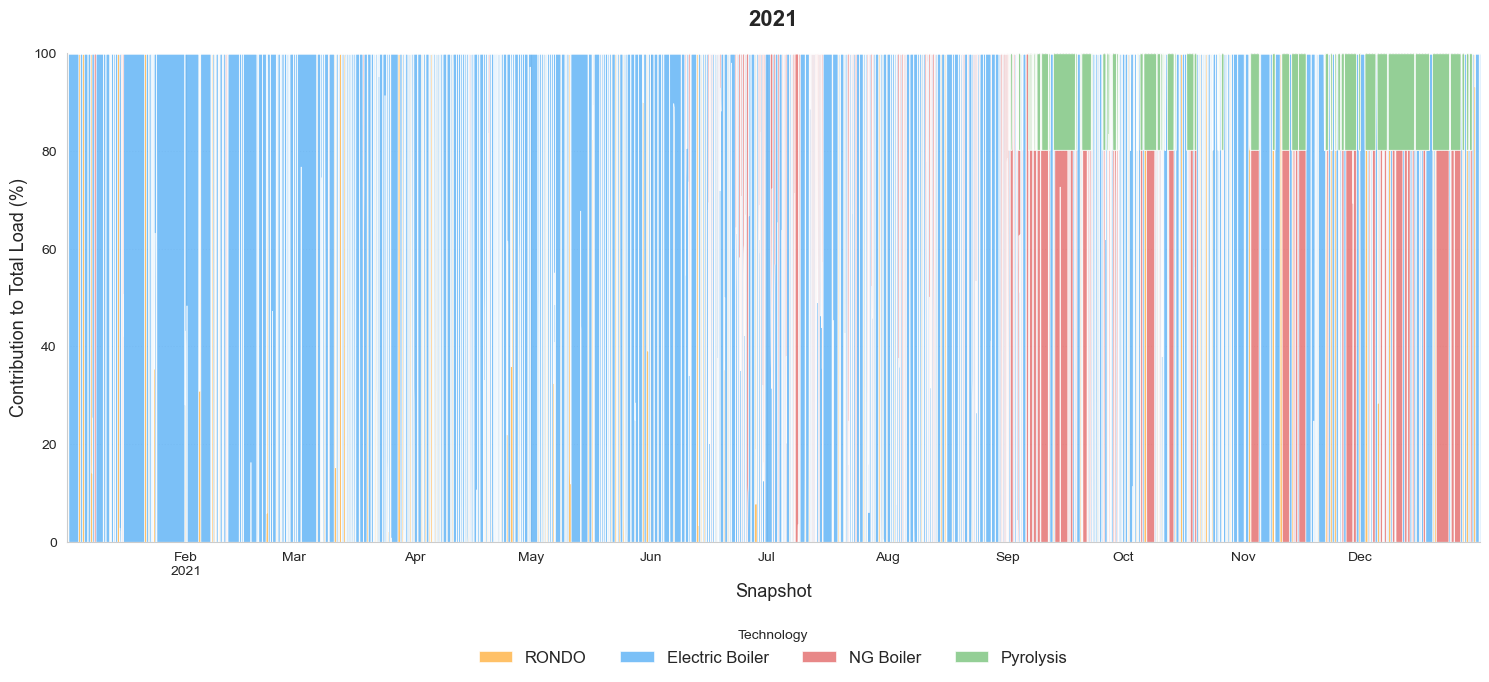

In [598]:
# 1. Gather data
heat_supply = pd.DataFrame({
    "RONDO": -n21.links_t.p1["Heat_Exchanger_Rondo"],
    "Electric Boiler": -n21.links_t.p1["Boiler_Skive"],
    "NG Boiler": -n21.links_t.p1["NG boiler"],
    "Pyrolysis": -n21.links_t.p1["pyrolysis"]
})

# 2. Normalize to percentages
heat_percent = heat_supply.div(heat_supply.sum(axis=1), axis=0) * 100

# 3. Define the professional palette
nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784']

# 4. Create the plot
fig, ax = plt.subplots(figsize=(15, 7))

# FIX: Removed 'edgecolor' from the .plot.area call. 
# Pandas area plots are stacked by default.
heat_percent.plot.area(ax=ax, alpha=0.85, color=nice_colors, linewidth=0)

# OPTIONAL FIX: If you want the white lines back, 
# we can add them manually to avoid the AttributeError
for poly in ax.collections:
    poly.set_edgecolor('white')
    poly.set_linewidth(0.5)

# 5. Formatting
plt.title("2021", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Contribution to Total Load (%)", fontsize=13)
plt.xlabel("Snapshot", fontsize=13)
plt.ylim(0, 100) 

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=4, frameon=False, fontsize=12, title="Technology")

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

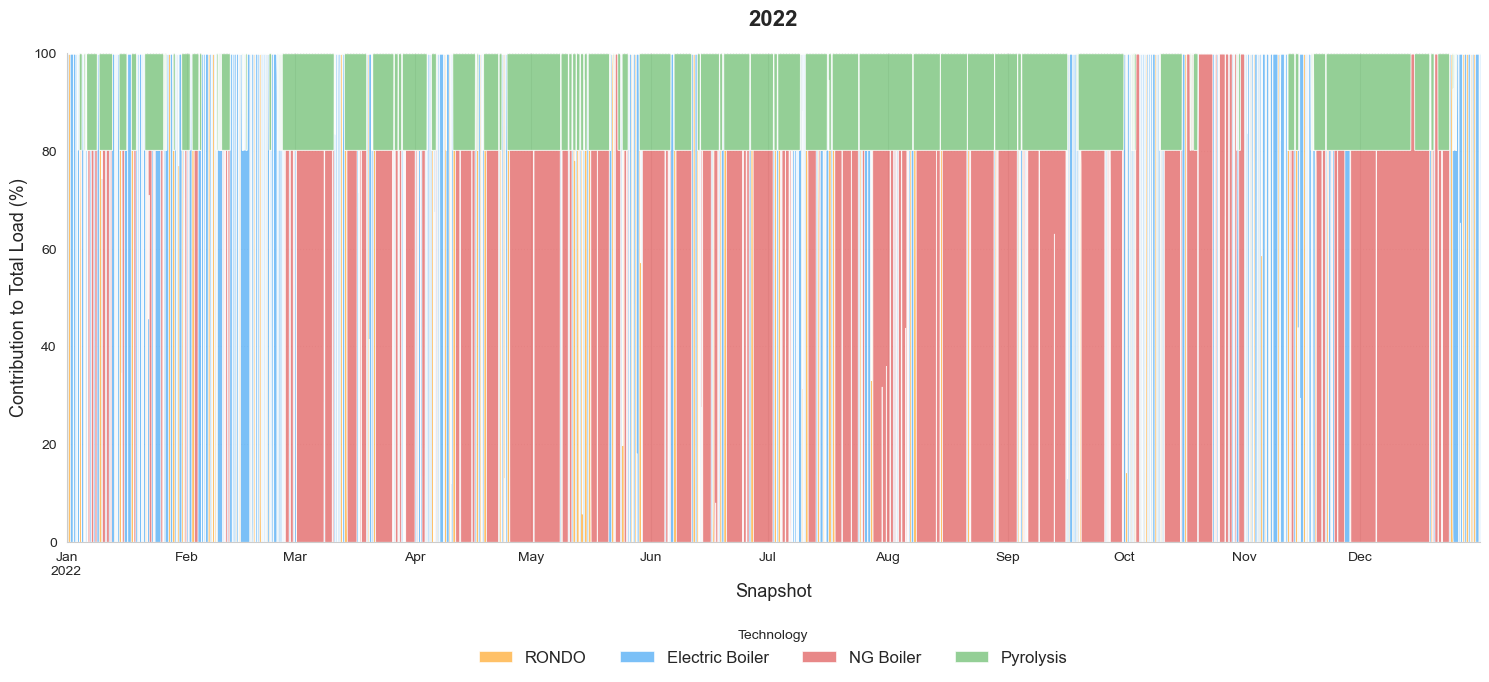

In [439]:
# 1. Gather data
heat_supply = pd.DataFrame({
    "RONDO": -n22.links_t.p1["Heat_Exchanger_Rondo"],
    "Electric Boiler": -n22.links_t.p1["Boiler_Skive"],
    "NG Boiler": -n22.links_t.p1["NG boiler"],
    "Pyrolysis": -n22.links_t.p1["pyrolysis"]
})

# 2. Normalize to percentages
heat_percent = heat_supply.div(heat_supply.sum(axis=1), axis=0) * 100

# 3. Define the professional palette
nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784']

# 4. Create the plot
fig, ax = plt.subplots(figsize=(15, 7))

# FIX: Removed 'edgecolor' from the .plot.area call. 
# Pandas area plots are stacked by default.
heat_percent.plot.area(ax=ax, alpha=0.85, color=nice_colors, linewidth=0)

# OPTIONAL FIX: If you want the white lines back, 
# we can add them manually to avoid the AttributeError
for poly in ax.collections:
    poly.set_edgecolor('white')
    poly.set_linewidth(0.5)

# 5. Formatting
plt.title("2022", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Contribution to Total Load (%)", fontsize=13)
plt.xlabel("Snapshot", fontsize=13)
plt.ylim(0, 100) 

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=4, frameon=False, fontsize=12, title="Technology")

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

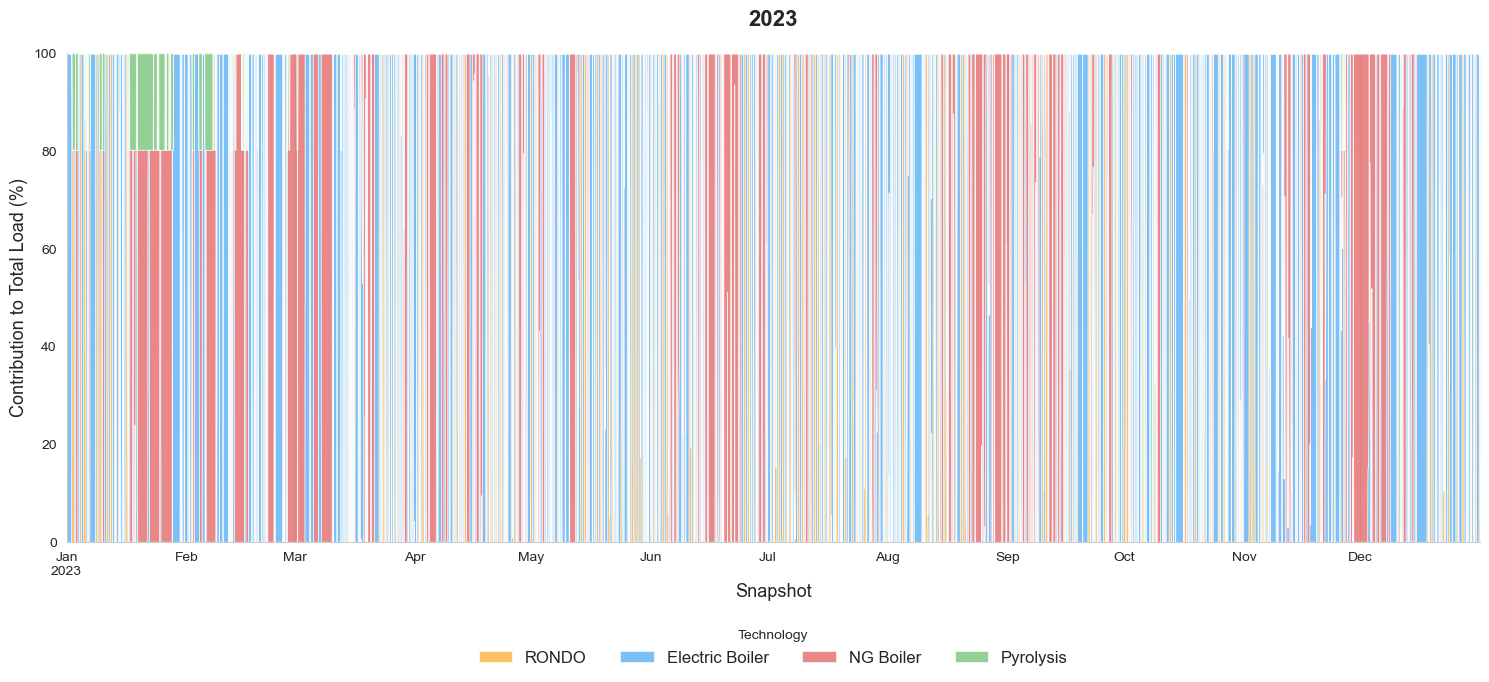

In [443]:
# 1. Gather data
heat_supply = pd.DataFrame({
    "RONDO": -n23.links_t.p1["Heat_Exchanger_Rondo"],
    "Electric Boiler": -n23.links_t.p1["Boiler_Skive"],
    "NG Boiler": -n23.links_t.p1["NG boiler"],
    "Pyrolysis": -n23.links_t.p1["pyrolysis"]
})

# 2. Normalize to percentages
heat_percent = heat_supply.div(heat_supply.sum(axis=1), axis=0) * 100

# 3. Define the professional palette
nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784']

# 4. Create the plot
fig, ax = plt.subplots(figsize=(15, 7))

# FIX: Removed 'edgecolor' from the .plot.area call. 
# Pandas area plots are stacked by default.
heat_percent.plot.area(ax=ax, alpha=0.85, color=nice_colors, linewidth=0)

# OPTIONAL FIX: If you want the white lines back, 
# we can add them manually to avoid the AttributeError
for poly in ax.collections:
    poly.set_edgecolor('white')
    poly.set_linewidth(0.5)

# 5. Formatting
plt.title("2023", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Contribution to Total Load (%)", fontsize=13)
plt.xlabel("Snapshot", fontsize=13)
plt.ylim(0, 100) 

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=4, frameon=False, fontsize=12, title="Technology")

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

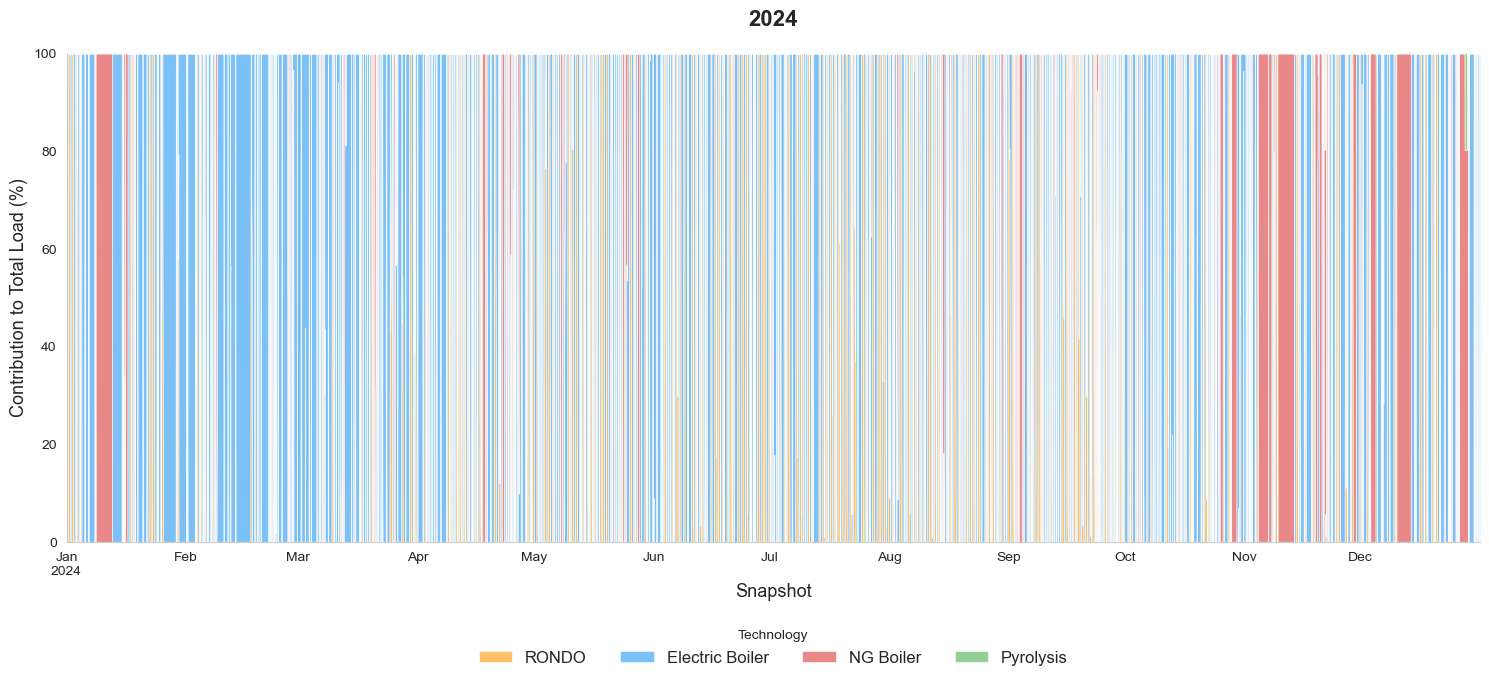

In [445]:
# 1. Gather data
heat_supply = pd.DataFrame({
    "RONDO": -n24.links_t.p1["Heat_Exchanger_Rondo"],
    "Electric Boiler": -n24.links_t.p1["Boiler_Skive"],
    "NG Boiler": -n24.links_t.p1["NG boiler"],
    "Pyrolysis": -n24.links_t.p1["pyrolysis"]
})

# 2. Normalize to percentages
heat_percent = heat_supply.div(heat_supply.sum(axis=1), axis=0) * 100

# 3. Define the professional palette
nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784']

# 4. Create the plot
fig, ax = plt.subplots(figsize=(15, 7))

# FIX: Removed 'edgecolor' from the .plot.area call. 
# Pandas area plots are stacked by default.
heat_percent.plot.area(ax=ax, alpha=0.85, color=nice_colors, linewidth=0)

# OPTIONAL FIX: If you want the white lines back, 
# we can add them manually to avoid the AttributeError
for poly in ax.collections:
    poly.set_edgecolor('white')
    poly.set_linewidth(0.5)

# 5. Formatting
plt.title("2024", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Contribution to Total Load (%)", fontsize=13)
plt.xlabel("Snapshot", fontsize=13)
plt.ylim(0, 100) 

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=4, frameon=False, fontsize=12, title="Technology")

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [456]:
# Save the network after optimization
n22.export_to_netcdf("Greenlab_Skive_2022_Results.nc")

INFO:pypsa.network.io:Exported network 'Unnamed Network'saved to 'Greenlab_Skive_2022_Results.nc contains: storage_units, buses, loads, carriers, links, stores, generators


<xarray.Dataset> Size: 5MB
Dimensions:                               (snapshots: 8760,
                                           investment_periods: 0,
                                           storage_units_i: 1,
                                           storage_units_t_p_i: 1,
                                           storage_units_t_p_dispatch_i: 1,
                                           storage_units_t_p_store_i: 1,
                                           ...
                                           links_t_p3_i: 1, links_t_p2_i: 1,
                                           stores_i: 4, stores_t_p_i: 3,
                                           stores_t_e_i: 3, generators_i: 5,
                                           generators_t_p_max_pu_i: 2,
                                           generators_t_marginal_cost_i: 1,
                                           generators_t_p_i: 5)
Coordinates: (12/26)
  * snapshots                             (snapshots) int64 70kB 0 1 ... 8759
  * investment_periods                    (investment_periods) object 0B 
  * storage_units_i                       (storage_units_i) object 8B 'Skive_...
  * storage_units_t_p_i                   (storage_units_t_p_i) object 8B 'Sk...
  * storage_units_t_p_dispatch_i          (storage_units_t_p_dispatch_i) object 8B ...
  * storage_units_t_p_store_i             (storage_units_t_p_store_i) object 8B ...
    ...                                    ...
  * stores_t_p_i                          (stores_t_p_i) object 24B 'Grid_Sto...
  * stores_t_e_i                          (stores_t_e_i) object 24B 'Grid_Sto...
  * generators_i                          (generators_i) object 40B 'Skive_So...
  * generators_t_p_max_pu_i               (generators_t_p_max_pu_i) object 16B ...
  * generators_t_marginal_cost_i          (generators_t_marginal_cost_i) object 8B ...
  * generators_t_p_i                      (generators_t_p_i) object 40B 'Skiv...
Data variables: (12/83)
    snapshots_snapshot                    (snapshots) datetime64[ns] 70kB 202...
    snapshots_objective                   (snapshots) float64 70kB 1.0 ... 1.0
    snapshots_stores                      (snapshots) float64 70kB 1.0 ... 1.0
    snapshots_generators                  (snapshots) float64 70kB 1.0 ... 1.0
    investment_periods_objective          (investment_periods) object 0B 
    investment_periods_years              (investment_periods) object 0B 
    ...                                    ...
    generators_up_time_before             (generators_i) int64 40B 1 1 1 1 1
    generators_down_time_before           (generators_i) int64 40B 0 0 0 0 0
    generators_p_nom_opt                  (generators_i) float64 40B 36.0 ......
    generators_t_p_max_pu                 (snapshots, generators_t_p_max_pu_i) float64 140kB ...
    generators_t_marginal_cost            (snapshots, generators_t_marginal_cost_i) float64 70kB ...
    generators_t_p                        (snapshots, generators_t_p_i) float64 350kB ...
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           -20279575.68295581
    network__objective_constant:  905174.1193812739
    network_name:                 Unnamed Network
    network_objective:            -20279575.68295581
    network_objective_constant:   905174.1193812739
    network_pypsa_version:        0.35.2
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}

In [453]:
# Save the network after optimization
n23.export_to_netcdf("Greenlab_Skive_2023_Results.nc")

INFO:pypsa.network.io:Exported network 'Unnamed Network'saved to 'Greenlab_Skive_2023_Results.nc contains: storage_units, buses, loads, carriers, links, stores, generators


<xarray.Dataset> Size: 5MB
Dimensions:                               (snapshots: 8760,
                                           investment_periods: 0,
                                           storage_units_i: 1,
                                           storage_units_t_p_i: 1,
                                           storage_units_t_p_dispatch_i: 1,
                                           storage_units_t_p_store_i: 1,
                                           ...
                                           links_t_p3_i: 1, links_t_p2_i: 1,
                                           stores_i: 4, stores_t_p_i: 3,
                                           stores_t_e_i: 3, generators_i: 5,
                                           generators_t_p_max_pu_i: 2,
                                           generators_t_marginal_cost_i: 1,
                                           generators_t_p_i: 5)
Coordinates: (12/26)
  * snapshots                             (snapshots) int64 70kB 0 1 ... 8759
  * investment_periods                    (investment_periods) object 0B 
  * storage_units_i                       (storage_units_i) object 8B 'Skive_...
  * storage_units_t_p_i                   (storage_units_t_p_i) object 8B 'Sk...
  * storage_units_t_p_dispatch_i          (storage_units_t_p_dispatch_i) object 8B ...
  * storage_units_t_p_store_i             (storage_units_t_p_store_i) object 8B ...
    ...                                    ...
  * stores_t_p_i                          (stores_t_p_i) object 24B 'Grid_Sto...
  * stores_t_e_i                          (stores_t_e_i) object 24B 'Grid_Sto...
  * generators_i                          (generators_i) object 40B 'Skive_So...
  * generators_t_p_max_pu_i               (generators_t_p_max_pu_i) object 16B ...
  * generators_t_marginal_cost_i          (generators_t_marginal_cost_i) object 8B ...
  * generators_t_p_i                      (generators_t_p_i) object 40B 'Skiv...
Data variables: (12/83)
    snapshots_snapshot                    (snapshots) datetime64[ns] 70kB 202...
    snapshots_objective                   (snapshots) float64 70kB 1.0 ... 1.0
    snapshots_stores                      (snapshots) float64 70kB 1.0 ... 1.0
    snapshots_generators                  (snapshots) float64 70kB 1.0 ... 1.0
    investment_periods_objective          (investment_periods) object 0B 
    investment_periods_years              (investment_periods) object 0B 
    ...                                    ...
    generators_up_time_before             (generators_i) int64 40B 1 1 1 1 1
    generators_down_time_before           (generators_i) int64 40B 0 0 0 0 0
    generators_p_nom_opt                  (generators_i) float64 40B 36.0 ......
    generators_t_p_max_pu                 (snapshots, generators_t_p_max_pu_i) float64 140kB ...
    generators_t_marginal_cost            (snapshots, generators_t_marginal_cost_i) float64 70kB ...
    generators_t_p                        (snapshots, generators_t_p_i) float64 350kB ...
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           -7265772.465518358
    network__objective_constant:  905174.1193812739
    network_name:                 Unnamed Network
    network_objective:            -7265772.465518358
    network_objective_constant:   905174.1193812739
    network_pypsa_version:        0.35.2
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}

In [455]:
# Save the network after optimization
n24.export_to_netcdf("Greenlab_Skive_2024_Results.nc")

INFO:pypsa.network.io:Exported network 'Unnamed Network'saved to 'Greenlab_Skive_2024_Results.nc contains: storage_units, buses, loads, carriers, links, stores, generators


<xarray.Dataset> Size: 5MB
Dimensions:                               (snapshots: 8784,
                                           investment_periods: 0,
                                           storage_units_i: 1,
                                           storage_units_t_p_i: 1,
                                           storage_units_t_p_dispatch_i: 1,
                                           storage_units_t_p_store_i: 1,
                                           ...
                                           links_t_p3_i: 1, links_t_p2_i: 1,
                                           stores_i: 4, stores_t_p_i: 3,
                                           stores_t_e_i: 3, generators_i: 5,
                                           generators_t_p_max_pu_i: 2,
                                           generators_t_marginal_cost_i: 1,
                                           generators_t_p_i: 5)
Coordinates: (12/26)
  * snapshots                             (snapshots) int64 70kB 0 1 ... 8783
  * investment_periods                    (investment_periods) object 0B 
  * storage_units_i                       (storage_units_i) object 8B 'Skive_...
  * storage_units_t_p_i                   (storage_units_t_p_i) object 8B 'Sk...
  * storage_units_t_p_dispatch_i          (storage_units_t_p_dispatch_i) object 8B ...
  * storage_units_t_p_store_i             (storage_units_t_p_store_i) object 8B ...
    ...                                    ...
  * stores_t_p_i                          (stores_t_p_i) object 24B 'Grid_Sto...
  * stores_t_e_i                          (stores_t_e_i) object 24B 'Grid_Sto...
  * generators_i                          (generators_i) object 40B 'Skive_So...
  * generators_t_p_max_pu_i               (generators_t_p_max_pu_i) object 16B ...
  * generators_t_marginal_cost_i          (generators_t_marginal_cost_i) object 8B ...
  * generators_t_p_i                      (generators_t_p_i) object 40B 'Skiv...
Data variables: (12/83)
    snapshots_snapshot                    (snapshots) datetime64[ns] 70kB 202...
    snapshots_objective                   (snapshots) float64 70kB 1.0 ... 1.0
    snapshots_stores                      (snapshots) float64 70kB 1.0 ... 1.0
    snapshots_generators                  (snapshots) float64 70kB 1.0 ... 1.0
    investment_periods_objective          (investment_periods) object 0B 
    investment_periods_years              (investment_periods) object 0B 
    ...                                    ...
    generators_up_time_before             (generators_i) int64 40B 1 1 1 1 1
    generators_down_time_before           (generators_i) int64 40B 0 0 0 0 0
    generators_p_nom_opt                  (generators_i) float64 40B 36.0 ......
    generators_t_p_max_pu                 (snapshots, generators_t_p_max_pu_i) float64 141kB ...
    generators_t_marginal_cost            (snapshots, generators_t_marginal_cost_i) float64 70kB ...
    generators_t_p                        (snapshots, generators_t_p_i) float64 351kB ...
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           -5734784.577476802
    network__objective_constant:  905174.1193812739
    network_name:                 Unnamed Network
    network_objective:            -5734784.577476802
    network_objective_constant:   905174.1193812739
    network_pypsa_version:        0.35.2
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}

In [446]:
# Save the network after optimization
n21.export_to_netcdf("Greenlab_Skive_2021_Results.nc")

INFO:pypsa.network.io:Exported network 'Unnamed Network'saved to 'Greenlab_Skive_2021_Results.nc contains: storage_units, buses, loads, carriers, links, stores, generators


<xarray.Dataset> Size: 5MB
Dimensions:                               (snapshots: 8754,
                                           investment_periods: 0,
                                           storage_units_i: 1,
                                           storage_units_t_p_i: 1,
                                           storage_units_t_p_dispatch_i: 1,
                                           storage_units_t_p_store_i: 1,
                                           ...
                                           links_t_p3_i: 1, links_t_p2_i: 1,
                                           stores_i: 4, stores_t_p_i: 3,
                                           stores_t_e_i: 3, generators_i: 5,
                                           generators_t_p_max_pu_i: 2,
                                           generators_t_marginal_cost_i: 1,
                                           generators_t_p_i: 5)
Coordinates: (12/26)
  * snapshots                             (snapshots) int64 70kB 0 1 ... 8753
  * investment_periods                    (investment_periods) object 0B 
  * storage_units_i                       (storage_units_i) object 8B 'Skive_...
  * storage_units_t_p_i                   (storage_units_t_p_i) object 8B 'Sk...
  * storage_units_t_p_dispatch_i          (storage_units_t_p_dispatch_i) object 8B ...
  * storage_units_t_p_store_i             (storage_units_t_p_store_i) object 8B ...
    ...                                    ...
  * stores_t_p_i                          (stores_t_p_i) object 24B 'Grid_Sto...
  * stores_t_e_i                          (stores_t_e_i) object 24B 'Grid_Sto...
  * generators_i                          (generators_i) object 40B 'Skive_So...
  * generators_t_p_max_pu_i               (generators_t_p_max_pu_i) object 16B ...
  * generators_t_marginal_cost_i          (generators_t_marginal_cost_i) object 8B ...
  * generators_t_p_i                      (generators_t_p_i) object 40B 'Skiv...
Data variables: (12/83)
    snapshots_snapshot                    (snapshots) datetime64[ns] 70kB 202...
    snapshots_objective                   (snapshots) float64 70kB 1.0 ... 1.0
    snapshots_stores                      (snapshots) float64 70kB 1.0 ... 1.0
    snapshots_generators                  (snapshots) float64 70kB 1.0 ... 1.0
    investment_periods_objective          (investment_periods) object 0B 
    investment_periods_years              (investment_periods) object 0B 
    ...                                    ...
    generators_up_time_before             (generators_i) int64 40B 1 1 1 1 1
    generators_down_time_before           (generators_i) int64 40B 0 0 0 0 0
    generators_p_nom_opt                  (generators_i) float64 40B 36.0 ......
    generators_t_p_max_pu                 (snapshots, generators_t_p_max_pu_i) float64 140kB ...
    generators_t_marginal_cost            (snapshots, generators_t_marginal_cost_i) float64 70kB ...
    generators_t_p                        (snapshots, generators_t_p_i) float64 350kB ...
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           -6456506.547492187
    network__objective_constant:  905174.1193812739
    network_name:                 Unnamed Network
    network_objective:            -6456506.547492187
    network_objective_constant:   905174.1193812739
    network_pypsa_version:        0.35.2
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}

In [451]:
n21.objective/1e6

-6.456506547492187

In [447]:
import pypsa
n_testing = pypsa.Network("Greenlab_Skive_2021_Results.nc")

# View specific results
print(n_testing.generators_t.p) # Hourly power for generators
print(n_testing.links_t.p1)     # H

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores


Generator            Skive_Solar  Skive_Onshore_Wind  Grid_Generator  NG grid  \
snapshot                                                                        
2021-01-01 06:00:00       0.0000            2.393973        2.504751      0.0   
2021-01-01 07:00:00       0.0000            2.213766        0.000000      0.0   
2021-01-01 08:00:00       0.4464            2.014209        0.000000      0.0   
2021-01-01 09:00:00       1.7208            1.708929        0.000000      0.0   
2021-01-01 10:00:00       2.7504            1.388970        0.000000      0.0   
...                          ...                 ...             ...      ...   
2021-12-31 19:00:00       0.0000           14.457969        0.000000      0.0   
2021-12-31 20:00:00       0.0000           14.578110        0.000000      0.0   
2021-12-31 21:00:00       0.0000           15.163074        0.000000      0.0   
2021-12-31 22:00:00       0.0000           16.735851        1.891006      0.0   
2021-12-31 23:00:00       0.